In [1]:
import pandas as pd
import numpy as np                          # for working with arrays and matrices
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

pd.set_option('display.max_rows', 500)      # Set max number of rows displayed
pd.set_option('display.max_columns', 500)   # Set max number of columns displayed
pd.set_option('display.width', 1000)

# Visualizations
import missingno as msno
import matplotlib.pyplot as plt             # for creating plots
from matplotlib.colors import ListedColormap
%matplotlib inline
import seaborn as sns
import plotly

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Avoid warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
from matplotlib import colors

# Customize the appearance of plots: (both the axes and the figure have a background color of #FFF9ED, which is a light beige color.)
sns.set(rc={"axes.facecolor":"#ffffef","figure.facecolor":"#ffffef"})

# cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])   # <-- `cmap` is short for colormap, which is used for mapping data values to colors in a plot.

<div style="background-color:  #dbf0c9; padding: 10px;">

### 1. Reading Data
</div>


In [3]:
df_train = pd.read_csv(PROJECT_ROOT / 'data' / 'train_final.csv')

df_test = pd.read_csv(PROJECT_ROOT / 'data' / 'test_final.csv')


<div style="background-color:  #dbf0c9; padding: 10px;">

### 2. General Information from Data
</div>


In [4]:
display(df_train.head(10))

display(df_test.head(10))

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,Resort Hotel,0,3,2016,February,7,12,0,2,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,E,F,0,No Deposit,0,Transient,81.00,1,0,2016-02-14
1,City Hotel,1,50,2016,November,47,18,1,2,2,0.0,0,BB,BEL,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,93.60,0,2,2016-10-09
2,City Hotel,0,14,2015,September,37,7,1,5,2,2.0,0,BB,ITA,Online TA,TA/TO,0,0,0,F,F,0,No Deposit,0,Contract,166.00,0,3,2015-09-13
3,City Hotel,0,18,2015,December,50,6,2,0,2,0.0,0,BB,ESP,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,107.00,0,0,2015-12-08
4,City Hotel,1,263,2016,September,40,29,2,4,2,0.0,0,BB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,100.30,0,0,2016-01-18
5,Resort Hotel,0,45,2016,March,10,1,0,5,2,0.0,0,HB,DEU,Groups,Direct,0,0,0,E,G,1,No Deposit,0,Transient,106.00,0,1,2016-03-06
6,Resort Hotel,0,131,2015,December,52,22,2,5,2,0.0,0,HB,AUS,Offline TA/TO,TA/TO,0,0,0,D,D,1,No Deposit,0,Transient-Party,72.14,0,1,2015-12-29
7,Resort Hotel,0,152,2017,July,28,11,2,5,2,0.0,0,HB,CHE,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient-Party,194.86,0,2,2017-07-18
8,City Hotel,0,102,2015,October,42,16,0,2,2,0.0,0,HB,DEU,Offline TA/TO,TA/TO,0,0,0,A,E,0,No Deposit,0,Transient-Party,109.00,0,0,2015-10-18
9,Resort Hotel,0,4,2017,April,17,26,0,2,1,0.0,0,BB,PRT,Corporate,Corporate,1,0,1,A,A,0,No Deposit,0,Transient,45.00,0,0,2017-04-28


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status_date
0,City Hotel,73,2016,July,28,6,0,2,1,0.0,0,SC,CN,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,107.10,0,0,2016-06-12
1,City Hotel,37,2015,October,43,24,2,5,1,1.0,0,SC,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,87.78,0,0,2015-10-31
2,City Hotel,190,2017,April,14,6,2,3,2,0.0,0,BB,PRT,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,88.40,0,0,2016-09-29
3,City Hotel,287,2016,August,35,24,1,4,2,0.0,0,BB,DEU,Direct,Direct,0,0,0,B,B,1,No Deposit,0,Transient,76.71,0,0,2016-08-29
4,Resort Hotel,386,2016,October,43,20,1,3,2,0.0,0,BB,PRT,Groups,Corporate,0,0,0,A,A,0,No Deposit,0,Transient-Party,49.00,0,0,2016-09-14
5,City Hotel,27,2015,September,40,30,0,2,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,0,0,0,A,A,0,Non Refund,21,Transient,108.00,0,0,2015-09-24
6,City Hotel,84,2017,April,15,11,0,4,3,0.0,0,BB,FRA,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,0,Transient,166.50,0,0,2017-01-22
7,City Hotel,7,2017,January,5,29,1,0,2,0.0,0,SC,FRA,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,88.00,0,1,2017-01-30
8,City Hotel,56,2016,June,24,8,0,1,2,0.0,0,BB,PRT,Offline TA/TO,Corporate,0,0,0,A,A,0,No Deposit,0,Transient-Party,120.00,0,0,2016-06-02
9,City Hotel,106,2016,November,45,4,1,2,2,0.0,0,BB,CHE,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,90.00,0,2,2016-07-28


<div style="background-color:  #dbf0c9; padding: 10px;">

- **market_segment** contains **distribution_channel** information. Both variables may be correlated, but both are available from the booking channel context and can be evaluated during modeling.
- **reserved_room_type** is known at booking time, while **assigned_room_type** may be assigned later by the hotel. For a realistic booking-time cancellation prediction problem, **assigned_room_type** should be removed from the model to avoid using information that may not be available when the prediction is made.

---
- **is_canceled** is the target, so it is not included in df_test. Therefore, I will predict the values of is_canceled for df_test.

</div>



In [5]:
 # Summary of data types and non-null counts in df_train
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44638 entries, 0 to 44637
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           44638 non-null  object 
 1   is_canceled                     44638 non-null  int64  
 2   lead_time                       44638 non-null  int64  
 3   arrival_date_year               44638 non-null  int64  
 4   arrival_date_month              44638 non-null  object 
 5   arrival_date_week_number        44638 non-null  int64  
 6   arrival_date_day_of_month       44638 non-null  int64  
 7   stays_in_weekend_nights         44638 non-null  int64  
 8   stays_in_week_nights            44638 non-null  int64  
 9   adults                          44638 non-null  int64  
 10  children                        44638 non-null  float64
 11  babies                          44638 non-null  int64  
 12  meal                            

In [6]:
 # Summary of data types and non-null counts in df_test
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23525 entries, 0 to 23524
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           23525 non-null  object 
 1   lead_time                       23525 non-null  int64  
 2   arrival_date_year               23525 non-null  int64  
 3   arrival_date_month              23525 non-null  object 
 4   arrival_date_week_number        23525 non-null  int64  
 5   arrival_date_day_of_month       23525 non-null  int64  
 6   stays_in_weekend_nights         23525 non-null  int64  
 7   stays_in_week_nights            23525 non-null  int64  
 8   adults                          23525 non-null  int64  
 9   children                        23525 non-null  float64
 10  babies                          23525 non-null  int64  
 11  meal                            23525 non-null  object 
 12  country                         

<div style="background-color:  #dbf0c9; padding: 10px;">

- **reservation_status_date** is datetime type
- **children** is int
- **is_canceled** is the target and is actually a qualitative variable represented by a binary value. They can remain like this as long as I interpret it correctly.

</div>


In [7]:
# Change the type of "children" to int
df_train['children'] = df_train['children'].astype('int64')
df_test['children'] = df_test['children'].astype('int64')

In [8]:
df_train['reservation_status_date'] = pd.to_datetime(df_train['reservation_status_date'])
df_test['reservation_status_date'] = pd.to_datetime(df_test['reservation_status_date'])

<div style="background-color:  #dbf0c9; padding: 10px;">

### 5. Detecting Missing Values

</div>


In [9]:
# Summary of missing values per features
miss_num = df_train.isna().sum()

miss_perc = round(miss_num/len(df_train)*100,1)

df_miss =pd.DataFrame({'No_missing': miss_num,
                       '%_missing': miss_perc})

print('Missing values summary per feature \n')
print('-------------------------------------------------------')
display(df_miss)

Missing values summary per feature 

-------------------------------------------------------


,No_missing,%_missing
hotel,0,0.0
is_canceled,0,0.0
lead_time,0,0.0
arrival_date_year,0,0.0
arrival_date_month,0,0.0
arrival_date_week_number,0,0.0
arrival_date_day_of_month,0,0.0
stays_in_weekend_nights,0,0.0
stays_in_week_nights,0,0.0
adults,0,0.0


<Figure size 1500x900 with 0 Axes>

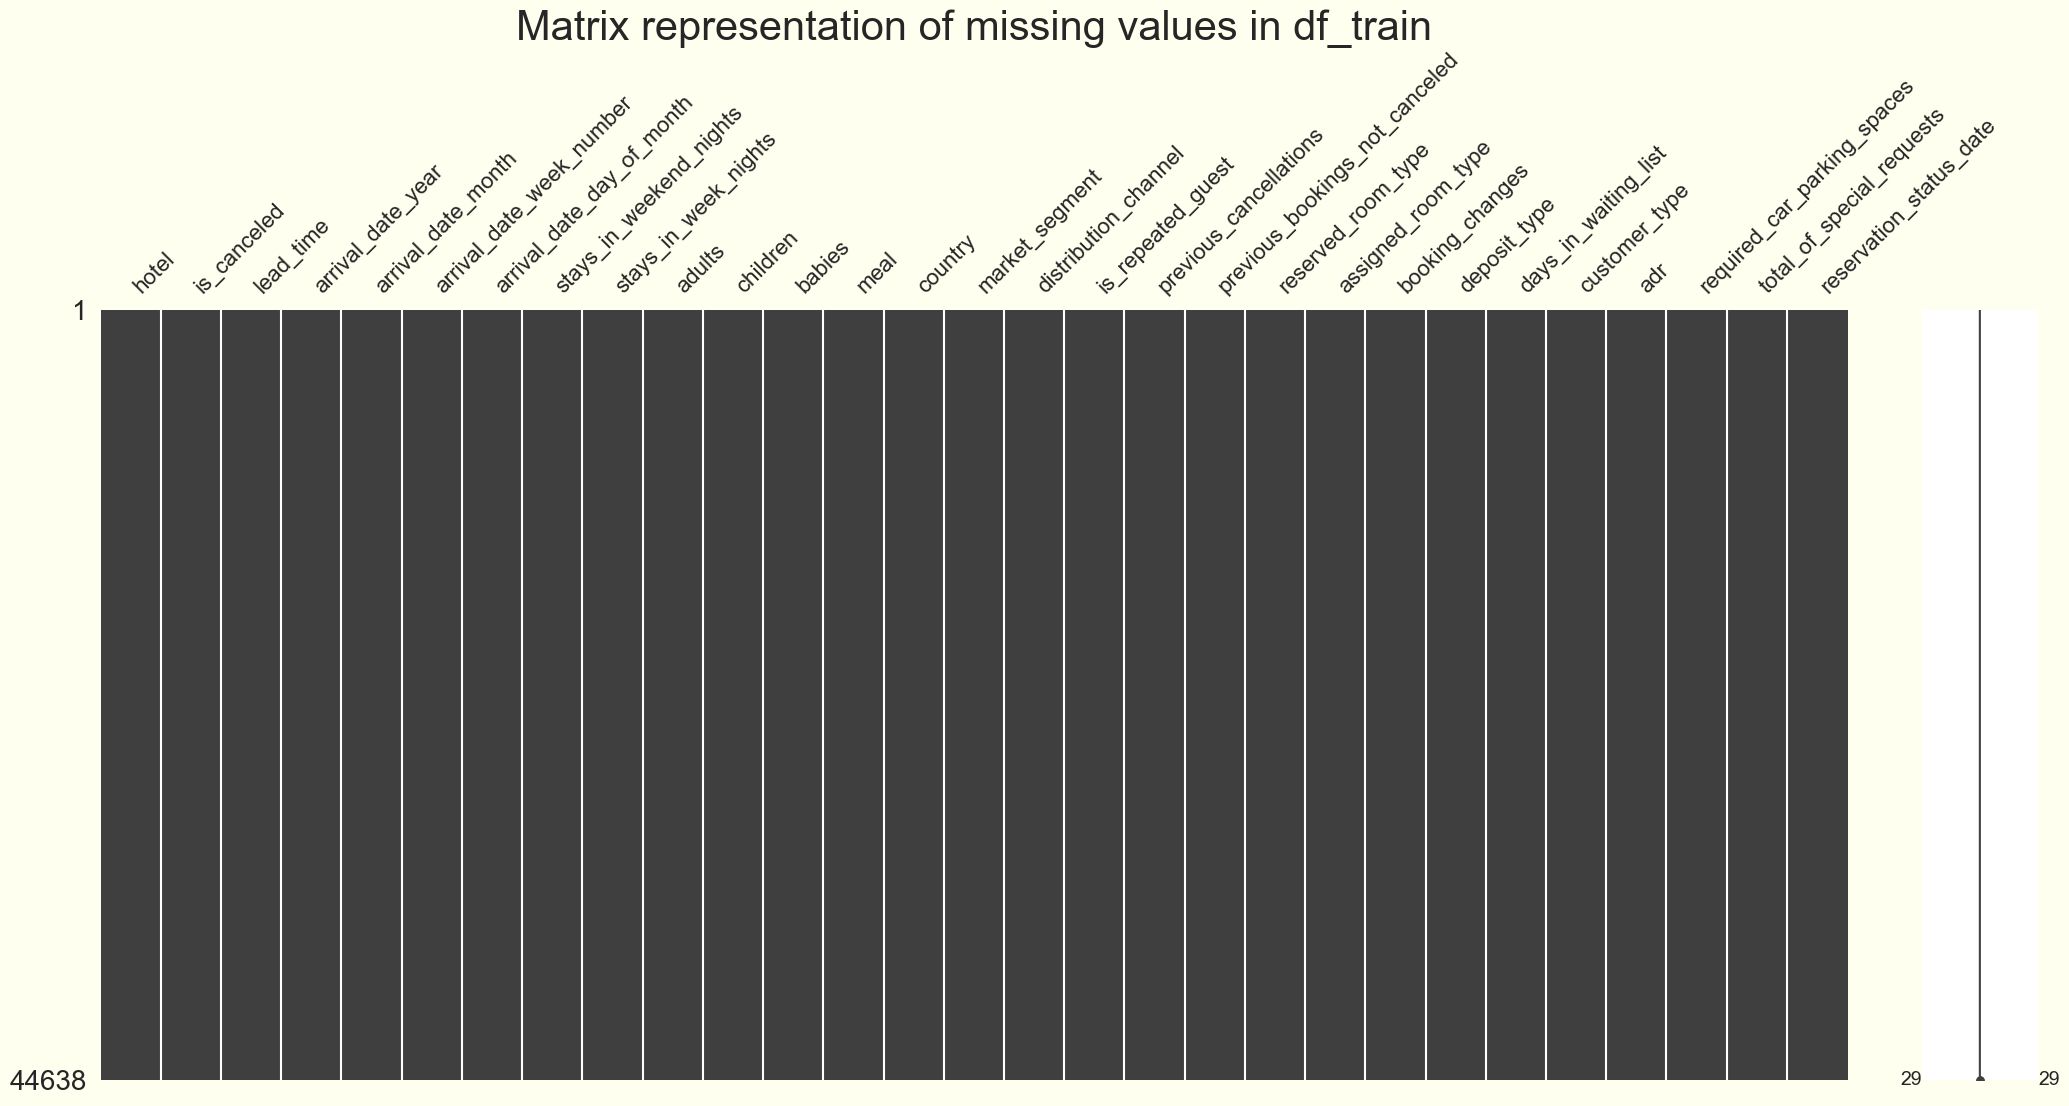

In [10]:
# Visual representation of missing values with missingno in df_train

# matrix
plt.figure(figsize = (15,9))
msno.matrix(df_train)
plt.title('Matrix representation of missing values in df_train', fontsize = 30)
plt.show();

<div style="background-color:  #dbf0c9; padding: 10px;">

**No missing values! YAY!**

</div>


<div style="background-color:  #f7dae3; padding: 10px;">

## Exploratory Data Analysis

</div>


In [11]:
# from ydata_profiling import ProfileReport
#
# profile = ProfileReport(df_train, explorative = True)
#
# # Saving results to a HTML file
# profile.to_file("HBD_report.html")

<div style="background-color:  #dbf0c9; padding: 10px;">

### 6. The Target

</div>


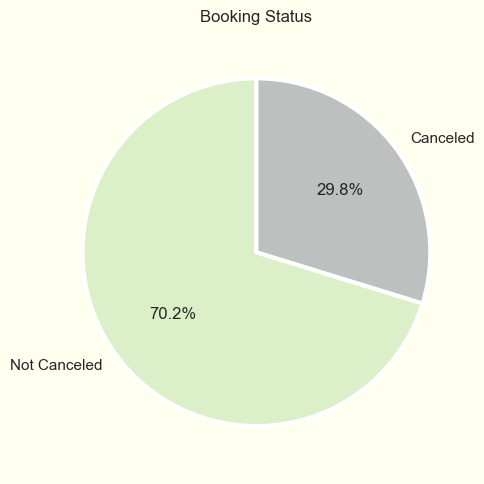

In [12]:
# Create data
booking_counts = df_train['is_canceled'].value_counts()
labels = ['Not Canceled', 'Canceled']  # Custom labels instead of 0 and 1
sizes = booking_counts.values

# --------------------------------------------------
# Pie Plot
fig, ax = plt.subplots(figsize = (5,5))

pcts = ax.pie(sizes,
              labels = labels,
              autopct = '%1.1f%%',
              colors = ['#dbf0c9', '#bcc0be'],
              wedgeprops={'linewidth': 3.0, 'edgecolor': 'white'},    # <------------- Style the wedges
              startangle = 90)

# Add a title
plt.title('Booking Status')

# Equal aspect ratio ensures that pie is drawn as a circle
plt.axis('equal')

plt.tight_layout()        # <------------- Adjust subplot spacing

# Display the chart
plt.show()

<div style="background-color:  #dbf0c9; padding: 10px;">

**The data is slightly unbalanced: Cancellation cases are 30% of the data, approximately**, meaning that, in the modeling stage, <font color=red>the accuracy metric could be affected when using a classification model</font>.

Appropriate techniques and analysis should be performed. Three possible options to solve the issue:

1- Using stratified splitting during train-test-split (split the data in a way that preserves the same proportions of cases in each class)
2- Choosing very carefully which outliers to drop (if any) to avoid deleting meaningful information (data points that are cancellations)
3- Applying resampling techniques (**Oversampling, Undersampling, SMOTE**)

</div>


<div style="background-color:  #dbf0c9; padding: 10px;">

### 7. Checking Numerical Columns

</div>


In [13]:
# Filtering quantitative columns
cols_num = [col for col in df_train.columns if df_train[col].dtype not in ['object', 'datetime64[ns]'] and col not in ['is_canceled', 'is_repeated_guest']]
cols_num

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

### Basic statistics of numerical columns


In [14]:
df_train.drop(['reservation_status_date', 'is_canceled'], axis = 1).describe().T.round()

,count,mean,std,min,25%,50%,75%,max
lead_time,44638.0,99.0,104.0,0.0,16.0,65.0,154.0,737.0
arrival_date_year,44638.0,2016.0,1.0,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_week_number,44638.0,27.0,14.0,1.0,16.0,27.0,38.0,53.0
arrival_date_day_of_month,44638.0,16.0,9.0,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,44638.0,1.0,1.0,0.0,0.0,1.0,2.0,16.0
stays_in_week_nights,44638.0,3.0,2.0,0.0,1.0,2.0,3.0,40.0
adults,44638.0,2.0,1.0,0.0,2.0,2.0,2.0,55.0
children,44638.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0
babies,44638.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0
is_repeated_guest,44638.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


<div style="background-color:  #dbf0c9; padding: 10px;">

I want to see if the mean and median are close, as this indicates a relatively balanced distribution. If there is a large difference, it suggests the variable has a skewed distribution, which could impact further analysis.

Some initial interesting information collected from the basic statistics of numerical variables are:

- **lead_time** seems to be skewed.
- The maximum number of **adults** for a reservation is 55. This could be an outlier (since the median and mean are similar and small, and std is also small) or just an entry error.
- **previous_cancellations**, **previous_bookings_not_canceled**, **booking_changes** and **days_in_waiting_list** also have too high maximum values, even when their median and rest of quantiles are 0. This aspect could mean nothing. I must perform further analysis.

---
- **children**, **babies**, **is_repeated_guest** and **arrival_date_year** are discrete variables that can be treated as categorical. This is because each distinct number can be seen a unique category rather than a measurable quantity.

</div>


### Plots of numerical columns



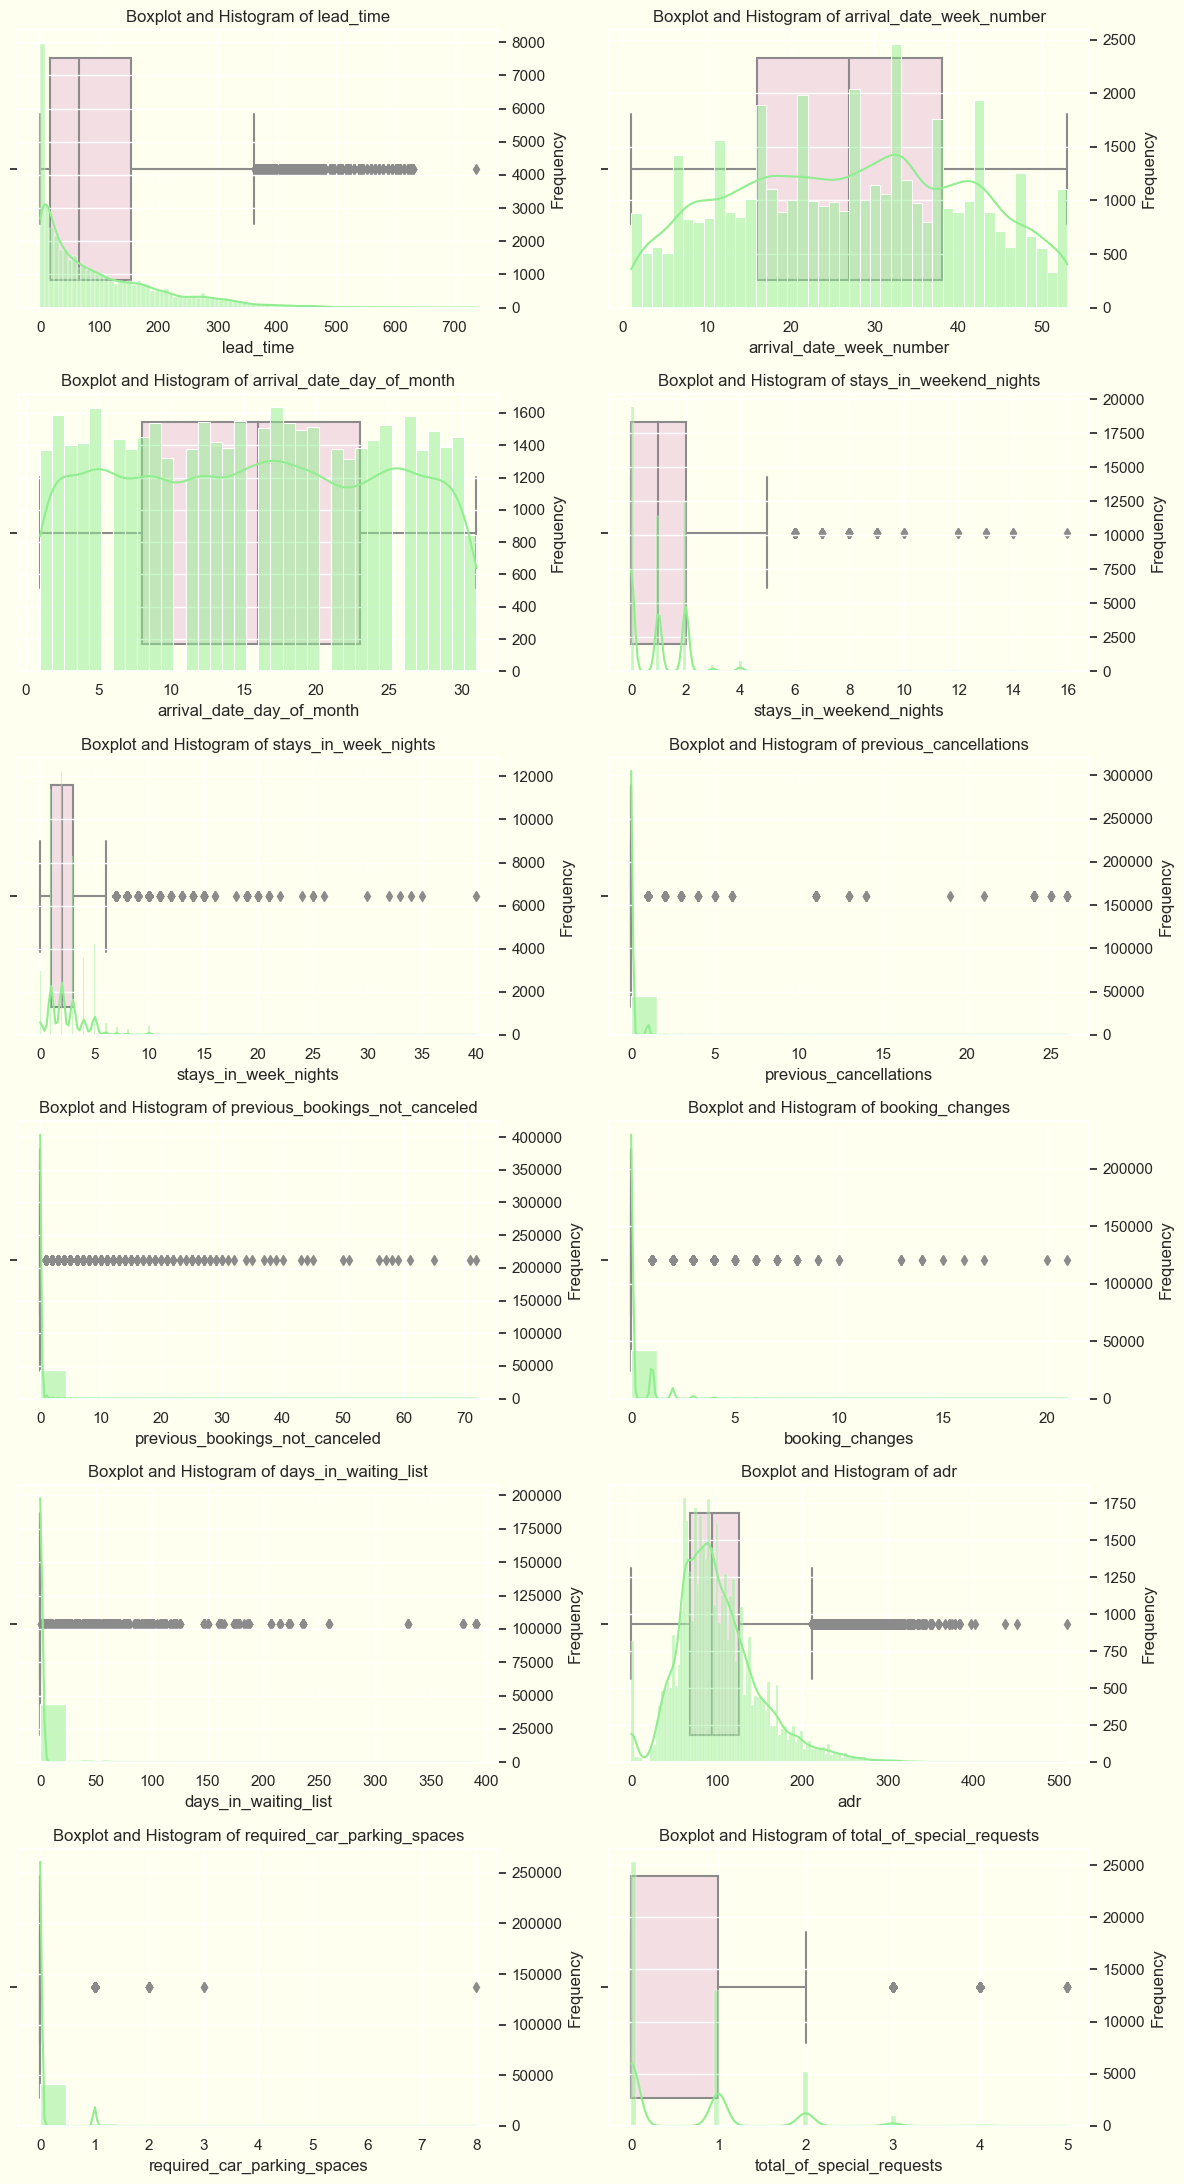

In [15]:
# Create list with numerical columns I want to create boxplots and histograms
cols_num_temp = [col for col in df_train.columns if df_train[col].dtype not in ['object', 'datetime64[ns]'] and col not in ['is_canceled', 'is_repeated_guest', 'arrival_date_year', 'adults', 'children', 'babies']]
# Define figure and axes grid
fig, axs = plt.subplots(nrows=6,
                        ncols=2,
                        figsize=(12, 22),
                        sharex=False)

# Loop over each subplot cell
for i, column in enumerate(cols_num_temp):
    row, col = divmod(i, 2)  # Determine row and column for each variable

    # Boxplot (top part of each cell)
    sns.boxplot(data=df_train,
                x=column,
                ax=axs[row, col],
                color="#f7dae3",
                orient='h')

    axs[row, col].set_title(f"Boxplot and Histogram of {column}")

    # Create a twin axis to overlay the histogram
    ax_hist = axs[row, col].twinx()

    # Histogram (bottom part of each cell)
    sns.histplot(data=df_train,
                 x=column,
                 kde=True,
                 ax=ax_hist,
                 color="lightgreen")

    ax_hist.set_ylabel("Frequency")

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


<div style="background-color:  #dbf0c9; padding: 10px;">

- **stays_in_weekend_nights**, **previous_cancellations**, **previous_bookings_not_canceled**, **booking_changes**, **days_in_waiting_list** and **total_of_special_requests** have a huge amount of zeros.
- **previous_cancellations**, **previous_bookings_not_canceled** and **lead_time** are highly skewed with outliers. Due to the domain specifications of these variables, I will only consider **lead_time**. However, even if a reservation made more than 400 days long is unusual it could still have an "impact" on whether this reservation is cancelled or not.
- **adr** has also outliers. There are rooms booked for free, also possible (contest, hotel workers awards, etc) and rooms with very high cost (high season, auctioned, etc)

---
- **required_car_parking_spaces** and **total_of_special_requests** are also discrete variables. I dont know yet, if I should treat them as categorical
</div>




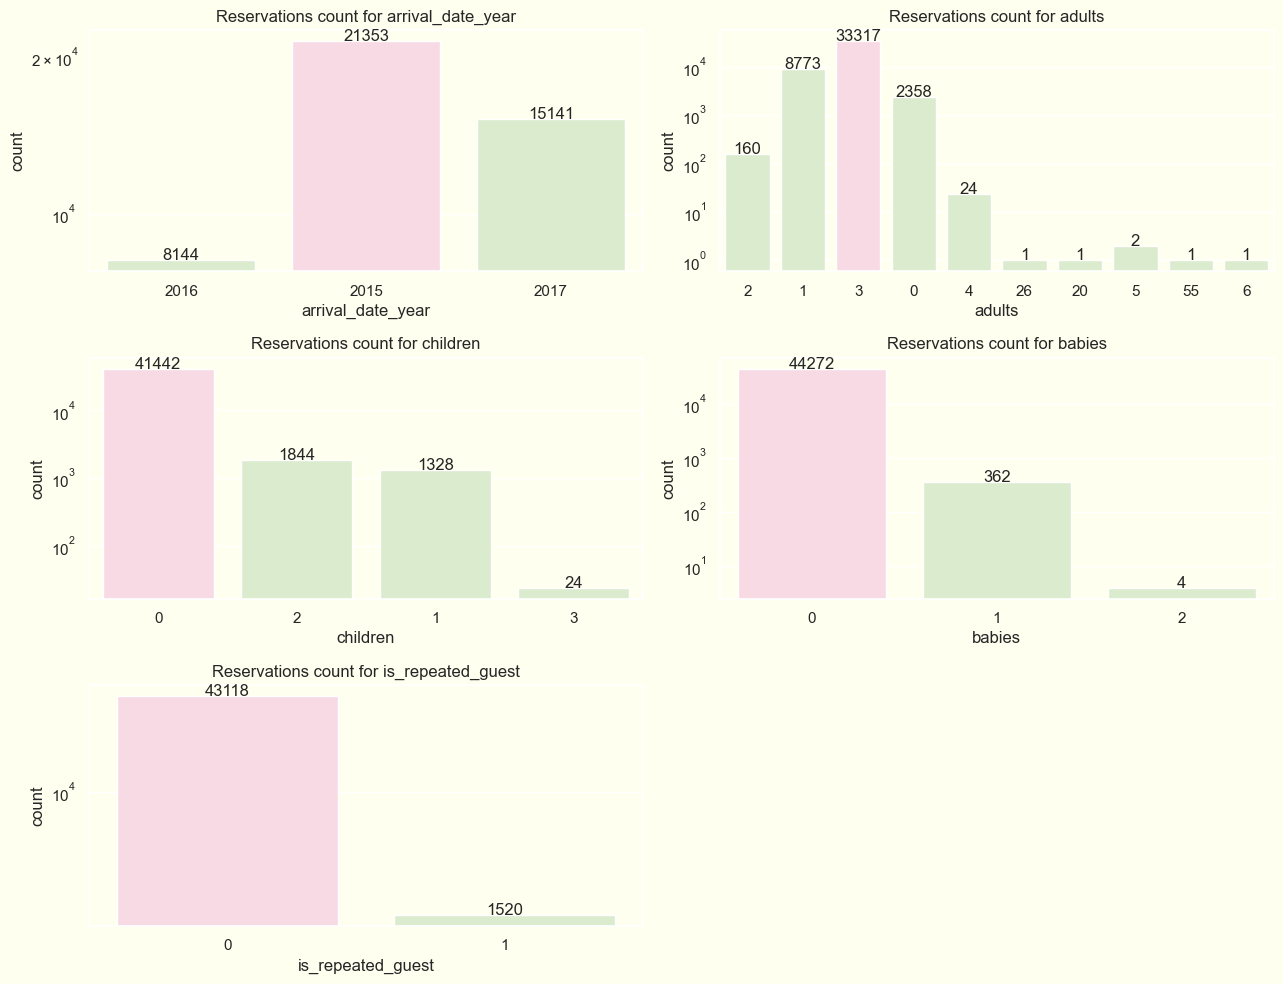

In [16]:
cols = ['arrival_date_year', 'adults', 'children', 'babies', 'is_repeated_guest']

plt.figure(figsize = (13,10))

for i, col in enumerate(cols):
    plt.subplot(3, 2, i+1)
    plt.gca().set_title('Reservations count for {}'.format(col))
    plt.gca().set_yscale('log')
    hist = sns.countplot(data = df_train,
                         x = col,
                         color = '#dbf0c9')

# Set x-tick labels as categories of the variable
    plt.gca().set_xticklabels(df_train[col].unique())

#   Placing the count (high of the bar) at each bar in the barplot
    for i, patch in enumerate(hist.patches):
          hist.annotate('{:.0f}'.format(patch.get_height()), (patch.get_x() + patch.get_width() / 2, patch.get_height()), ha = 'center')

# Highlight the bar the maximum count of reservations
    patch_h = [patch.get_height() for patch in hist.patches]  # <--------- list with the hights of the bars
    idx_tallest = np.argmax(patch_h)                          # <--------- get the index of the tallest bar
    hist.patches[idx_tallest].set_facecolor('#f7dae3')          # <--------- modify the color of the tallest bar

plt.tight_layout()     # <------------- Adjust subplot spacing
plt.show;

<div style="background-color:  #dbf0c9; padding: 10px;">

- **children** and **babies** are highly imbalanced.
- **adults** is highly skewed
</div>


### Numerical variables based on the cancellations


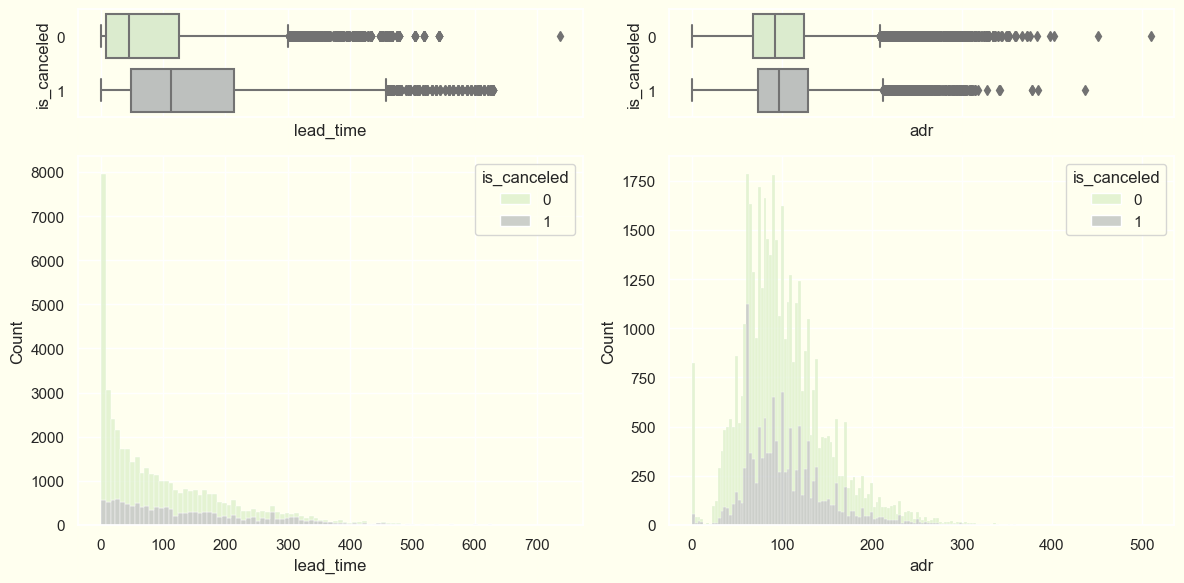

In [17]:
cols_num_1 = ['lead_time', 'adr']

# Setting the width of bins for each variable
binwidth = {'lead_time': 5,
            'adr': 10}

palette = ['#dbf0c9', '#bcc0be']

fig, axs = plt.subplots(nrows = 2,
                        ncols = 2,
                        sharex = 'col',
#                         sharey = 'row',
                        figsize = (12,6),
                        gridspec_kw={"height_ratios": (.25, .85)})

# plt.gca().set_yscale('log')

sns.boxplot(data = df_train,
            x = 'lead_time',
            y = 'is_canceled',
            ax = axs[0,0],
            orient = 'h',
           palette = palette)

sns.histplot(data = df_train,
             x = 'lead_time',
             hue = 'is_canceled',
             multiple='stack',
             palette = palette,
             ax = axs[1,0])

sns.boxplot(data = df_train,
            x = 'adr',
            y = 'is_canceled',
            ax = axs[0,1],
            palette = palette,
            orient = 'h')

sns.histplot(data = df_train,
             x = 'adr',
             hue = 'is_canceled',
             multiple='stack',
             palette = palette,
             ax = axs[1,1]);

plt.tight_layout()                   # Adjust subplot spacing


<div style="background-color:  #dbf0c9; padding: 10px;">

### 13. Checking the Categorical Columns in the Dataset

</div>


In [18]:
cols_cat = [col for col in df_train.columns if df_train[col].dtype == 'object']
cols_cat

['hotel',
 'arrival_date_month',
 'meal',
 'country',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'assigned_room_type',
 'deposit_type',
 'customer_type']

### Unique values of categorical columns


In [19]:
# Display unique values for each categorical column
unique_values_summary = {col: df_train[col].unique() for col in cols_cat}

print("Unique values in each categorical column:")

for col, unique_vals in unique_values_summary.items():
    print(f"{col}: {len(unique_vals)} unique values -> {unique_vals[:5]}{'...' if len(unique_vals) > 7 else ''}")

# Optional: Count the unique values per column
print("\nNumber of unique values in each column:")
print(df_train[cols_cat].nunique())

Unique values in each categorical column:
hotel: 2 unique values -> ['Resort Hotel' 'City Hotel']
arrival_date_month: 12 unique values -> ['February' 'November' 'September' 'December' 'March']...
meal: 5 unique values -> ['BB' 'HB' 'SC' 'Undefined' 'FB']
country: 156 unique values -> ['PRT' 'BEL' 'ITA' 'ESP' 'DEU']...
market_segment: 7 unique values -> ['Direct' 'Online TA' 'Groups' 'Offline TA/TO' 'Corporate']
distribution_channel: 4 unique values -> ['Direct' 'TA/TO' 'Corporate' 'GDS']
reserved_room_type: 9 unique values -> ['E' 'A' 'F' 'D' 'C']...
assigned_room_type: 11 unique values -> ['F' 'A' 'G' 'D' 'E']...
deposit_type: 3 unique values -> ['No Deposit' 'Non Refund' 'Refundable']
customer_type: 4 unique values -> ['Transient' 'Contract' 'Transient-Party' 'Group']

Number of unique values in each column:
hotel                     2
arrival_date_month       12
meal                      5
country                 156
market_segment            7
distribution_channel      4
reserved_r

- **country** has many categories. The Hotels receive reservations of guest from many countries.
    - What is the country with more reservations?
    - What country has more cancellations?
- **market_segment** and **distribution_channel** contain common categories and may capture related booking-channel information.
- **reserved_room_type** and **assigned_room_type** contain common categories, but only reserved room type is appropriate for a booking-time prediction model.


### Descriptive properties of categorical columns


In [20]:
df_train.describe(include =['object']).T

,count,unique,top,freq
hotel,44638,2,City Hotel,29335
arrival_date_month,44638,12,August,5232
meal,44638,5,BB,34424
country,44638,156,PRT,16999
market_segment,44638,7,Online TA,21325
distribution_channel,44638,4,TA/TO,36298
reserved_room_type,44638,9,A,31897
assigned_room_type,44638,11,A,27069
deposit_type,44638,3,No Deposit,40235
customer_type,44638,4,Transient,32982


- **hotel**: The dataset contains data from two Hotels, mostly from City Hotel.
- **country**: The reservations are made from 156 different countries. Most of the customers are portuguese.
- **arrival_date_month**: There are bookings for every month in the year, although most of the reservations are made in August.
- **meal**, **distribution_channel**, **reserved_room_type**, **deposit_type** are highly imbalanced.
- **assigned_room_type**: This field appears to reflect a later operational assignment and will not be used in the final booking-time prediction model.


- **customer_type**: The most common type of customer is _Transient_ which bring some interesting points:
    - A "Transient" customer refers to a guest who books a room for a short stay and is not part of a group, contract, or tour booking.
    - These guests typically book individually rather than through a corporate, travel agency, or group booking.
    - They often stay for a short period, such as a night or a few days.
    - They, usually, are traveling for leisure, business, or other individual purposes, as opposed to attending an organized event or conference.
    - They provide a high margin of revenue to the hotel, given that their bookings tend to be direct and are often made close to the stay date, allowing hotels to adjust rates dynamically based on demand.


### Bar plots of Categorical Columns


In [21]:
def cust_bars(counts):
    '''
    Function to set the heads of each bar with the percentage from the total for each category
    parameter: counts - the countplot of a categorical column
    '''
    # Set x-tick labels with rotation for specified columns
    if col in ['arrival_date_month', 'market_segment']:
        plt.xticks(rotation=45)
    else:
        plt.gca().set_xticklabels(df_train[col].unique())

    #   Placing the count (high of the bar) at each bar in the barplot
    for i, patch in enumerate(counts.patches):
          counts.annotate('{:.2f}%'.format(100* patch.get_height() / len(df_train)), (patch.get_x() + patch.get_width() / 2, patch.get_height() + 2), ha = 'center')

    # Highlight the bar the maximum count of reservations
    patch_c = [patch.get_height() for patch in counts.patches]  # <--------- list with the hights of the bars
    idx_tallest = np.argmax(patch_c)                          # <--------- get the index of the tallest bar
    counts.patches[idx_tallest].set_facecolor('#f7dae3')          # <--------- modify the color of the tallest bar

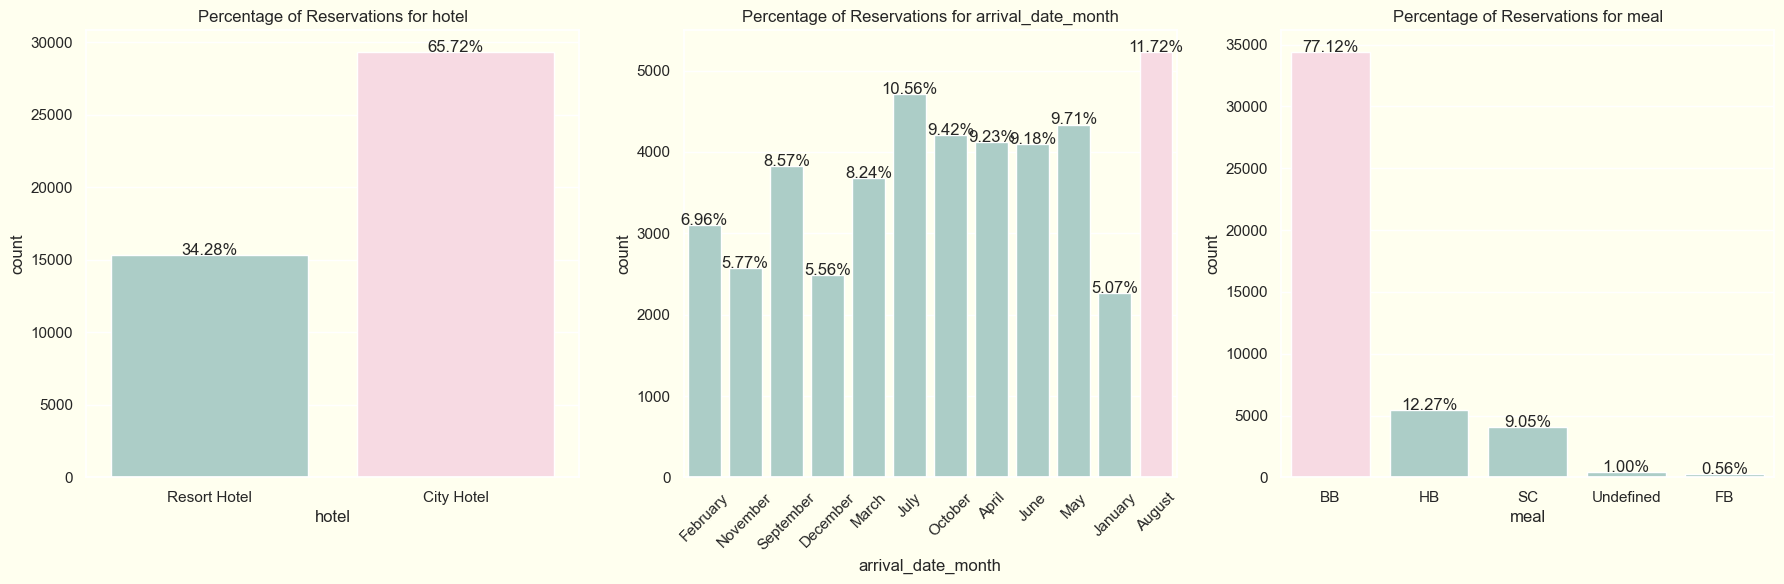

In [22]:
cols_cat_1 = ['hotel', 'arrival_date_month', 'meal']

# Define figure size
plt.figure(figsize=(18, 6))

# Loop through each categorical variable
for i, col in enumerate(cols_cat_1):
    plt.subplot(1, 3, i+1)
    plt.gca().set_title('Percentage of Reservations for {}'.format(col))
    # plt.gca().set_yscale('log')

    # Calculate percentage for each category and store in a DataFrame
    category_counts = df_train[col].value_counts(normalize=True) * 100  # normalize=True gives proportions, multiply by 100 for percentage

    # Create bar plot using percentage values
    counts = sns.countplot(data=df_train,
                           x=col,
                           color='#A7D2CB')

    cust_bars(counts)

plt.tight_layout()  # Adjust subplot spacing
plt.show()

- **meal**: 77.12% of the total count of reservations pick _BB_, leaving the rest of the categories under 13%. With this column having 5 categories, maybe it is a good idea, for the modeling stage, to group the rest of categories, except _BB_ .
- **arrival_date_month**: High-Season: From April to October — the months with more reservations.
- **hotel**: _City Hotel_ receive double of reservations than _Resort Hotel_.


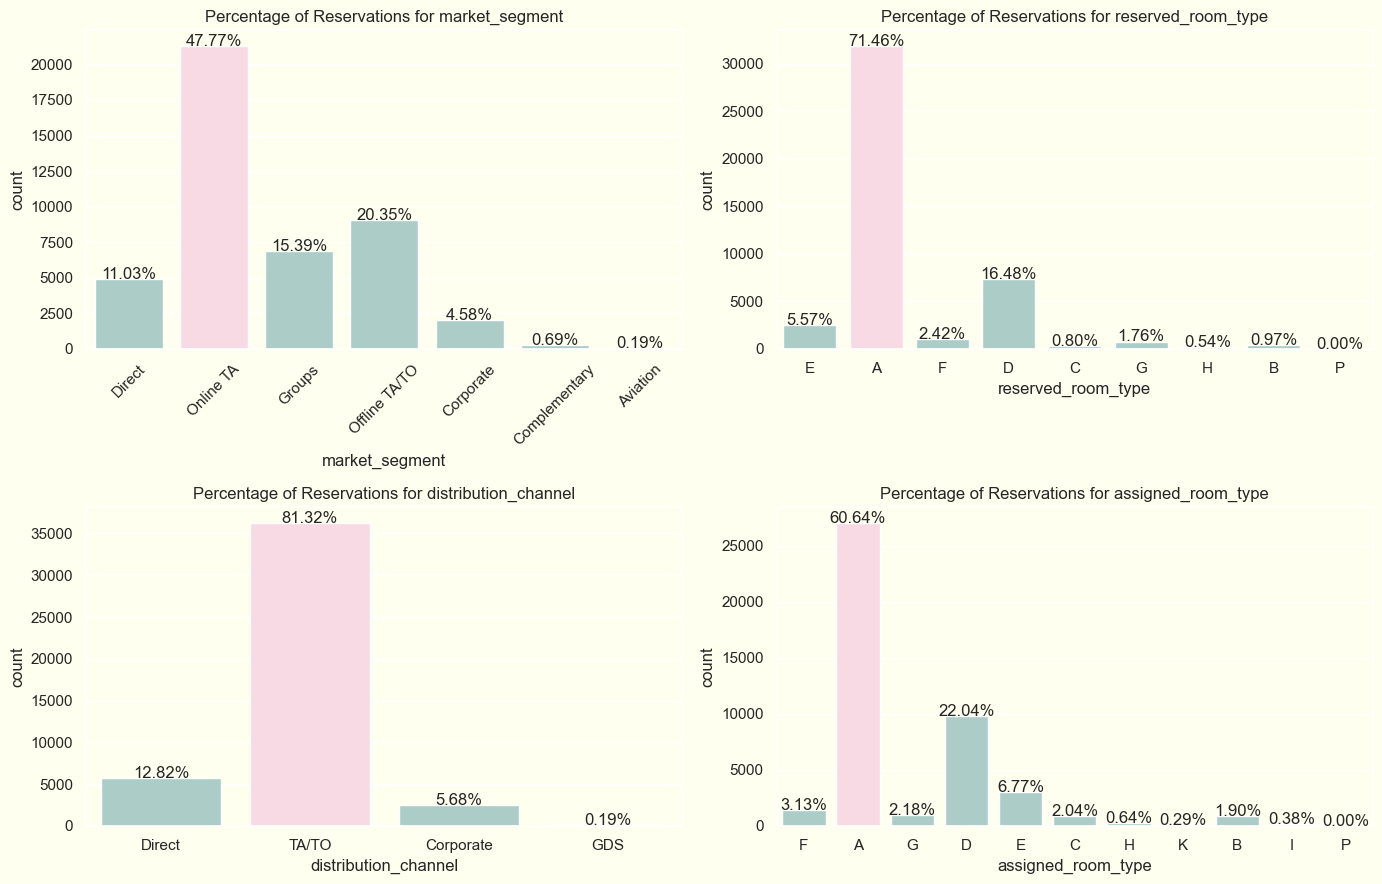

In [23]:
cols_cat_2 = ['market_segment', 'reserved_room_type', 'distribution_channel', 'assigned_room_type']

# Define figure size
plt.figure(figsize=(14, 9))

# Loop through each categorical variable
for i, col in enumerate(cols_cat_2):
    plt.subplot(2, 2, i+1)
    plt.gca().set_title('Percentage of Reservations for {}'.format(col))
    # plt.gca().set_yscale('log')

    # Calculate percentage for each category and store in a DataFrame
    category_counts = df_train[col].value_counts(normalize=True) * 100  # normalize=True gives proportions, multiply by 100 for percentage

    # Create bar plot using percentage values
    counts = sns.countplot(data=df_train,
                           x=col,
                           color='#A7D2CB')

    cust_bars(counts)

plt.tight_layout()  # Adjust subplot spacing
plt.show()

Important info based on the common categories between **market_segment** and **distribution_channel**:

### Market Segment attribute
The market segment refers to the type of customer or booking category based on the origin or purpose of the booking. It helps categorize guests by **why** or **how** they booked the stay.
Category description:
- **Direct**: Bookings made directly through the hotel's website, phone, or walk-ins.
- **Corporate**: Bookings made by corporate clients, often for business purposes.
- **Online Travel Agencies (OTA)**: Bookings made through platforms like Booking.com, Expedia, etc.
- **Groups**: Bookings for groups, such as corporate events, weddings, or large families.
- **Offline Travel Agents (TA/TO)**: Bookings made through traditional travel agents or tour operators, offline.
- **Complementary**: Rooms provided free of charge (e.g., for promotional purposes).
- **Aviation**: Bookings made by airline crew or other aviation-related personnel.

---

### Distribution Channel attribute
The distribution channel refers to the method or platform through which a reservation was made. It focuses on the route the booking took to reach the hotel. It focuses on **how** the guest's booking reached the hotel (through which platform or system).
Categories description:
- **Direct**: Bookings made directly with the hotel (through the hotel's website, phone, or walk-ins).
- **TA/TO (Travel Agent / Tour Operator)**: Bookings made through offline or traditional travel agents and tour operators.
- **GDS (Global Distribution System)**: Bookings made through a large networked reservation system that connects travel agents and companies to hotels, airlines, car rental services, etc. Examples include Amadeus, Sabre, and Travelport.
- **Corporate**: Direct bookings made by companies for their employees.

---

_These two categories together give hotels the necessary data to track and analyze their bookings and revenue streams from different sources._


- **market_segment** and **distribution_channel**: These variables contain related booking-channel information. I will keep both in the model at this stage because they may capture complementary patterns in how reservations are made.
- **reserved_room_type** and **assigned_room_type**: These variables are strongly related, but only **reserved_room_type** is clearly available at booking time. I will remove **assigned_room_type** before modeling to avoid using information that may not be available when the prediction is made.


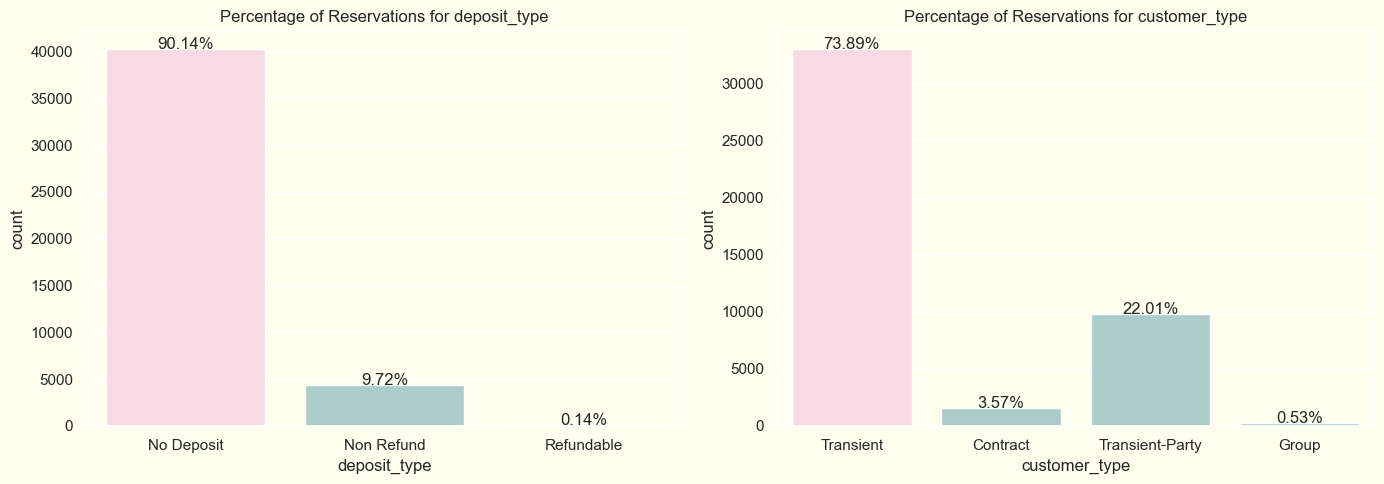

In [24]:
cols_cat_3 = ['deposit_type', 'customer_type']

# Define figure size
plt.figure(figsize=(14, 5))

# Loop through each categorical variable
for i, col in enumerate(cols_cat_3):
    plt.subplot(1, 2, i+1)
    plt.gca().set_title('Percentage of Reservations for {}'.format(col))
    # plt.gca().set_yscale('log')

    # Calculate percentage for each category and store in a DataFrame
    category_counts = df_train[col].value_counts(normalize=True) * 100  # normalize=True gives proportions, multiply by 100 for percentage

    # Create bar plot using percentage values
    counts = sns.countplot(data=df_train,
                           x=col,
                           color='#A7D2CB')

    cust_bars(counts)

plt.tight_layout()  # Adjust subplot spacing
plt.show()

- **deposit_type**: Highly imbalanced. 90% of total has no deposit, leaving a 9% for non refund and under 1% for refundable reservation.


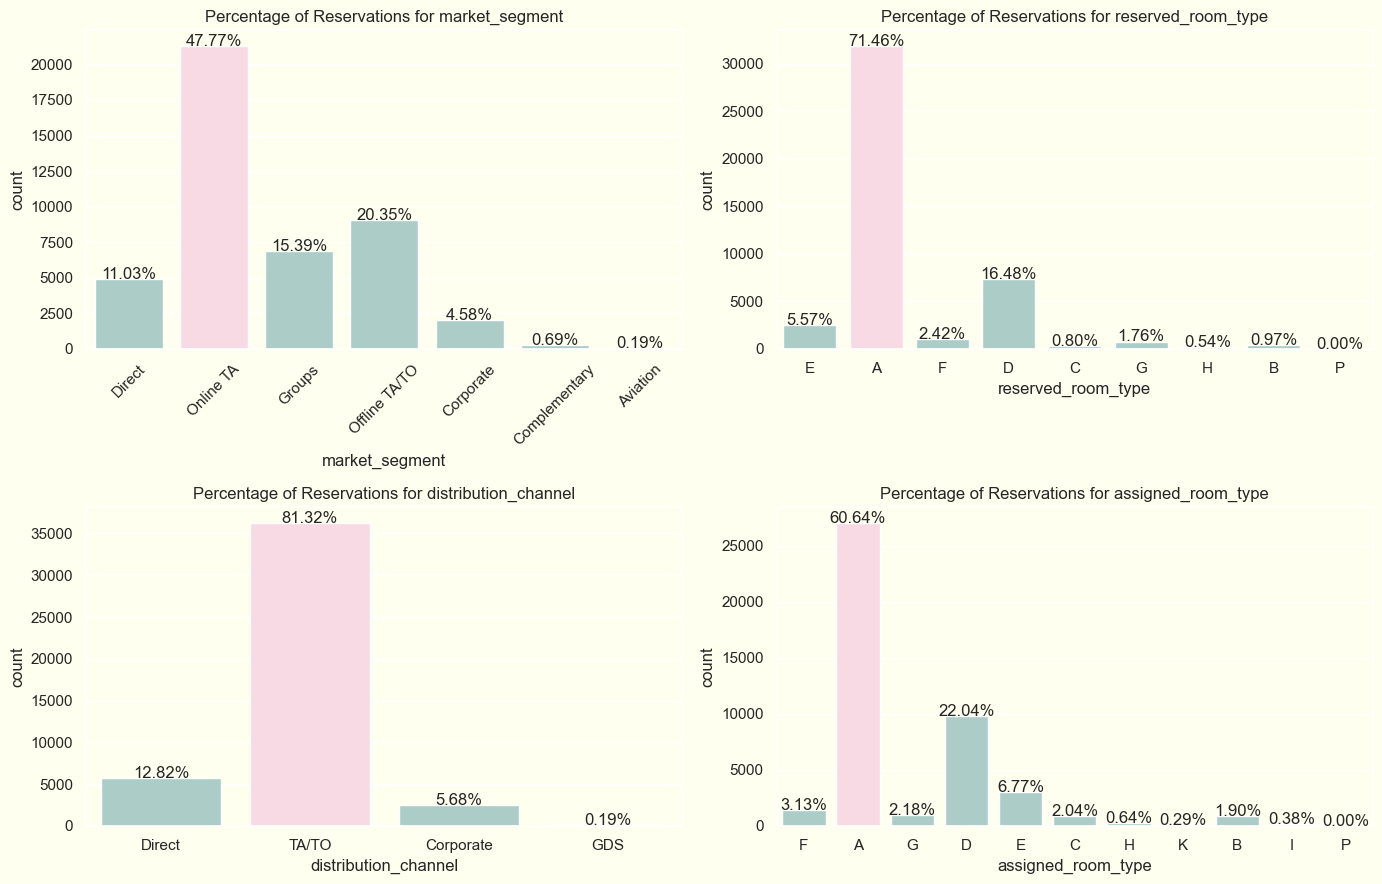

In [25]:
cols_cat_2 = ['market_segment', 'reserved_room_type', 'distribution_channel', 'assigned_room_type']

# Define figure size
plt.figure(figsize=(14, 9))

# Loop through each categorical variable
for i, col in enumerate(cols_cat_2):
    plt.subplot(2, 2, i+1)
    plt.gca().set_title('Percentage of Reservations for {}'.format(col))
    # plt.gca().set_yscale('log')

    # Calculate percentage for each category and store in a DataFrame
    category_counts = df_train[col].value_counts(normalize=True) * 100  # normalize=True gives proportions, multiply by 100 for percentage

    # Create bar plot using percentage values
    counts = sns.countplot(data=df_train,
                           x=col,
                           color='#A7D2CB')

    cust_bars(counts)

plt.tight_layout()  # Adjust subplot spacing
plt.show()

### Bar plots of Categorical Columns based on the target (is_canceled)


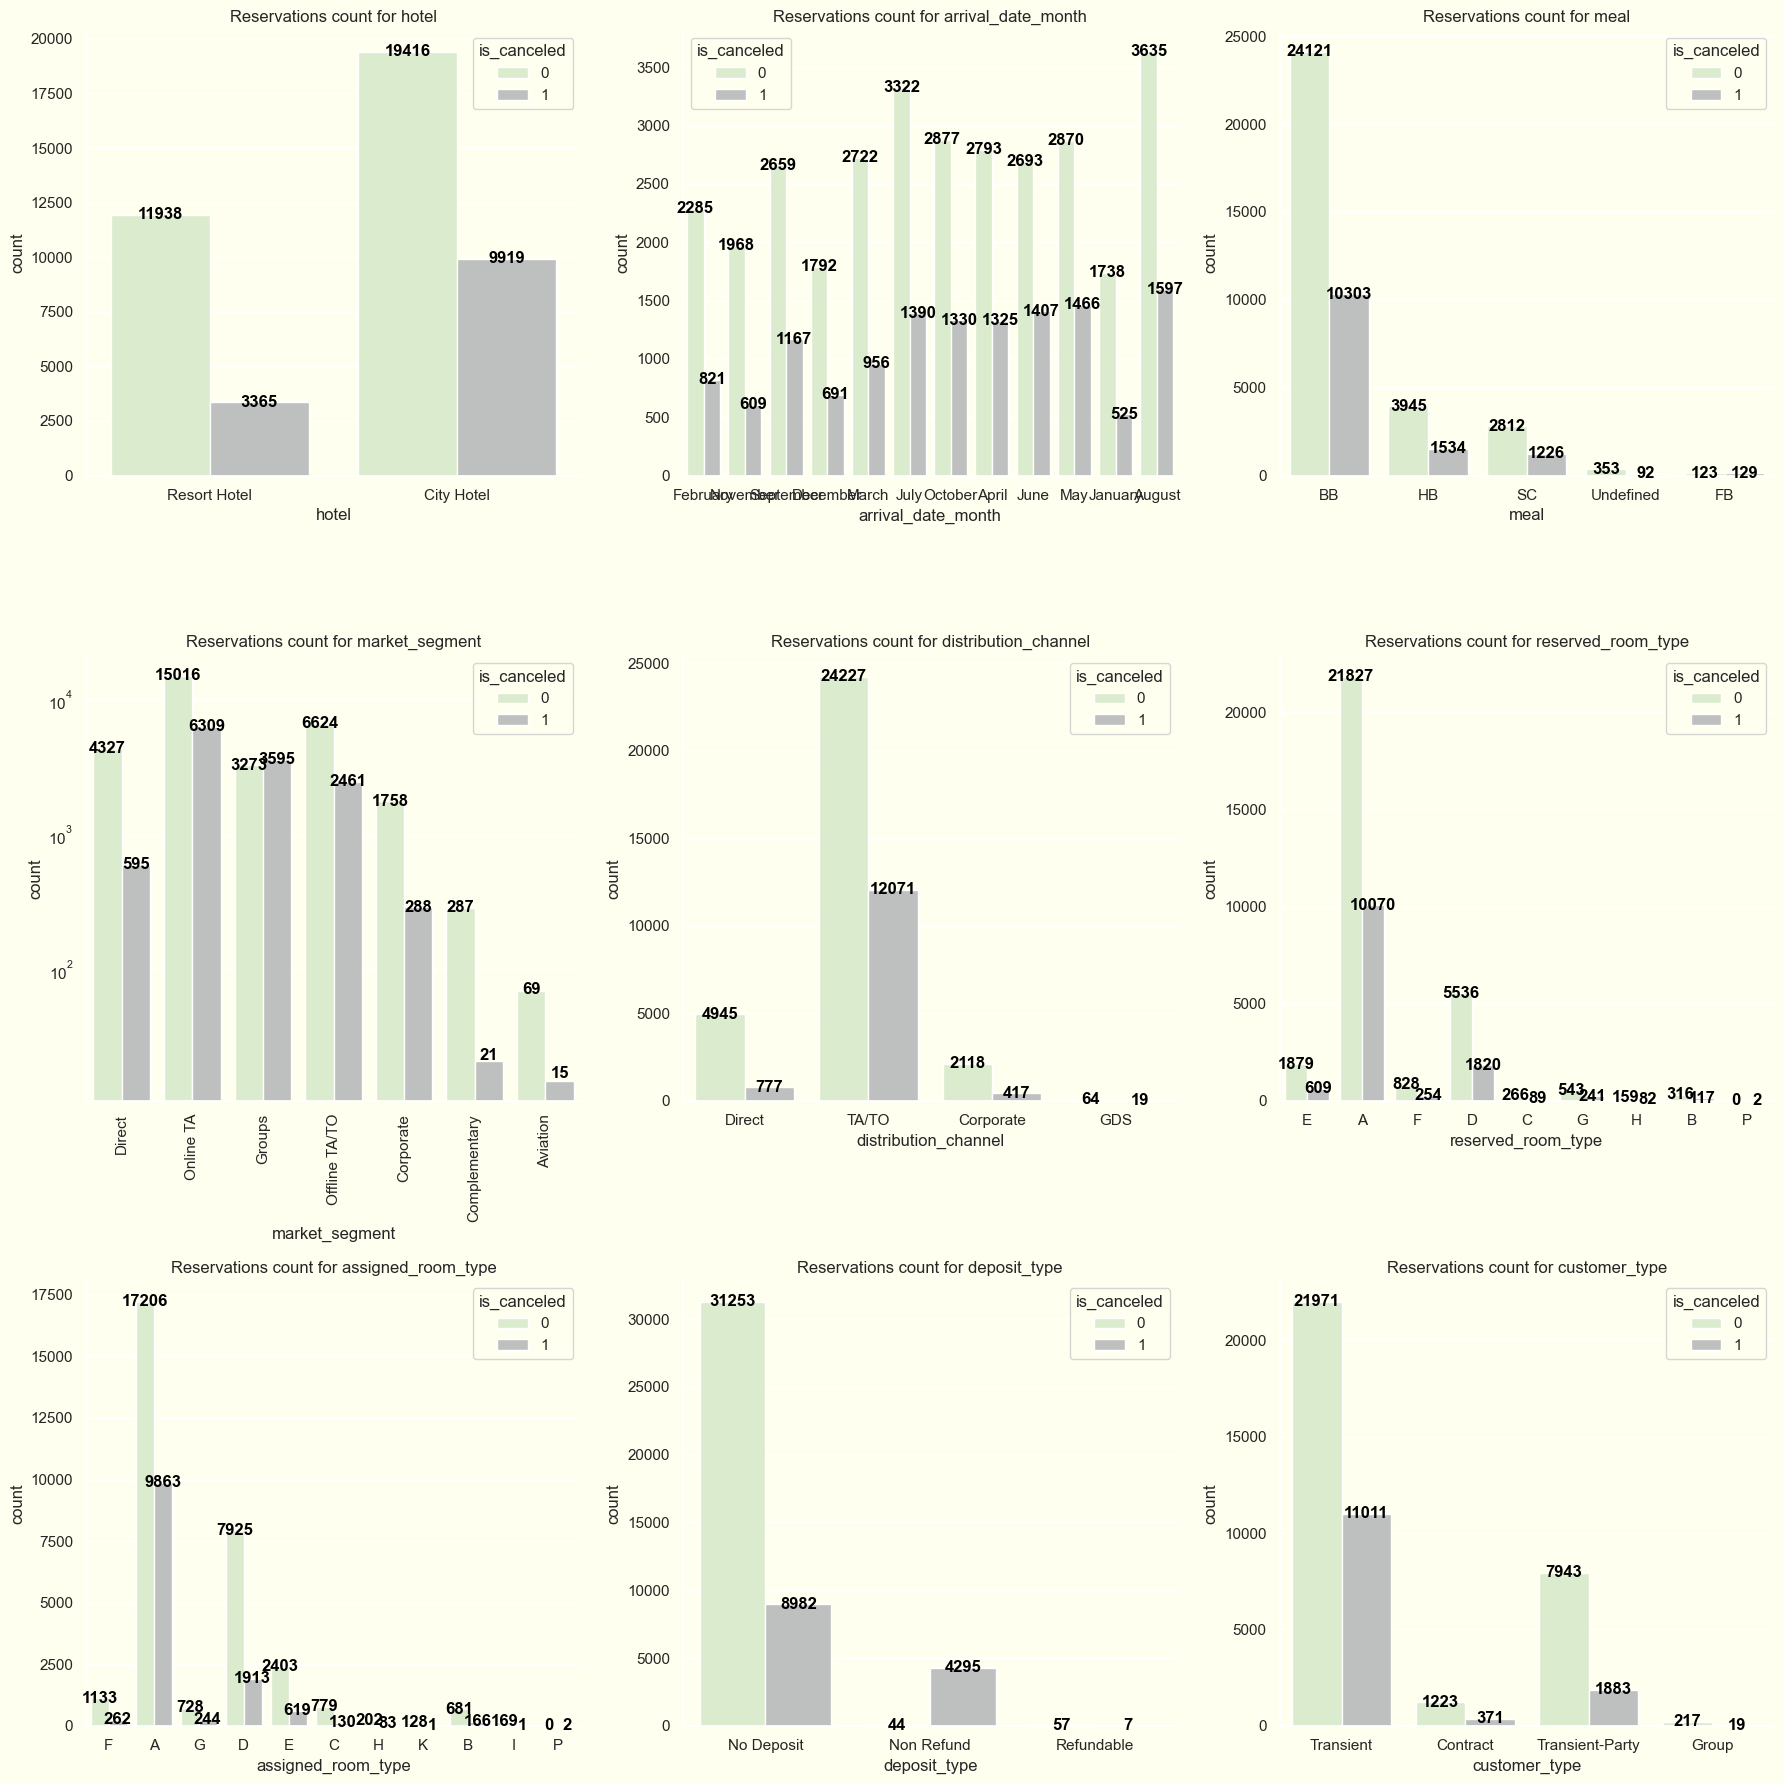

In [26]:
cols_cat_nc = [col for col in df_train.columns if df_train[col].dtype == 'object' and col != 'country']

plt.figure(figsize = (18,18))

for i, col in enumerate(cols_cat_nc):
    plt.subplot(3, 3, i+1)
    plt.gca().set_title('Reservations count for {}'.format(col))

    counts = sns.countplot(data = df_train,
                           x = col,
                           palette = ['#dbf0c9', '#bcc0be'],
                           hue = 'is_canceled')

    if col in ['market_segment']:
        plt.gca().set_yscale('log')
        counts.set_xticklabels(counts.get_xticklabels(), rotation=90)

    #   Placing the count (high of the bar) at each bar in the barplot
    for i, patch in enumerate(counts.patches):
        counts.annotate('{}'.format(int(patch.get_height())),
                        (patch.get_x() + patch.get_width() / 2, patch.get_height() + 2),
                        ha = 'center',
                        va = 'center',
                        fontsize = 12,
                        color = 'black',
                        weight = 'bold')

sns.despine()
plt.tight_layout()
plt.show;

In [27]:
df_train['is_canceled'].value_counts()

is_canceled
0    31354
1    13284
Name: count, dtype: int64

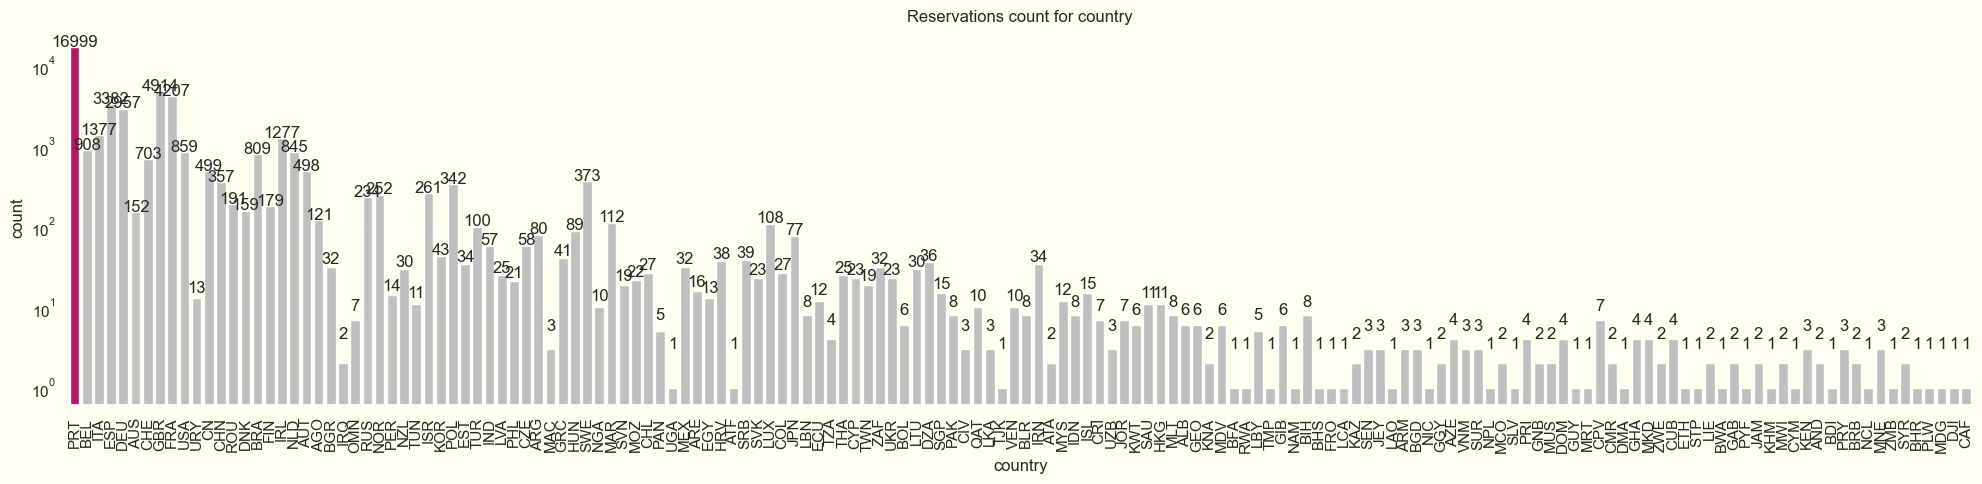

In [28]:
plt.figure(figsize=(20, 5))

for i, col in enumerate(['country']):
    plt.subplot(1, 1, i+1)
    plt.gca().set_title('Reservations count for {}'.format(col))
    counts = sns.countplot(data = df_train,
                           x = col,
                           color = '#bcc0be')

    if col in ['country']:
        plt.gca().set_yscale('log')
        counts.set_xticklabels(counts.get_xticklabels(), rotation=90)

  #   Placing the count (high of the bar) at each bar in the barplot
    for i, patch in enumerate(counts.patches):
        counts.annotate('{}'.format(int(patch.get_height())),
                        (patch.get_x() + patch.get_width() / 2, patch.get_height() + 2),
                        ha = 'center')

    # Highlight the bar the maximum count of reservations
    patch_c = [patch.get_height() for patch in counts.patches]
    idx_tallest = np.argmax(patch_c)
    counts.patches[idx_tallest].set_facecolor('#b51963')

sns.despine()
plt.tight_layout()
plt.show;

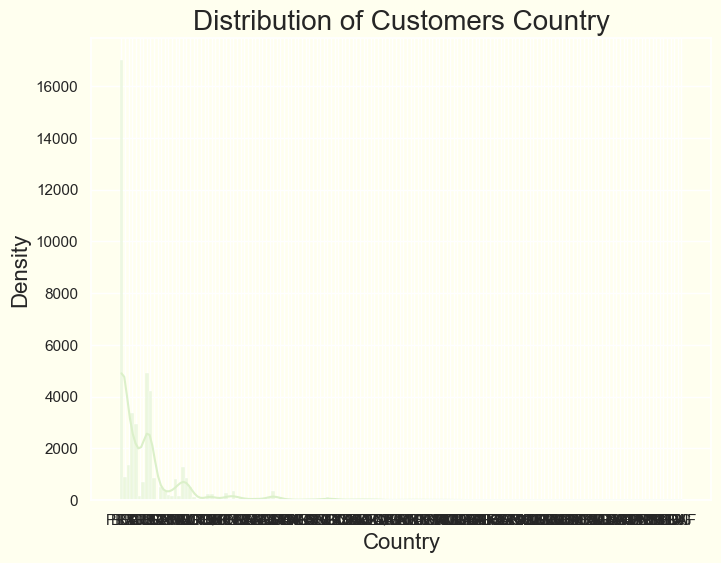

In [29]:
# sns.set(font_scale=1.3)

plt.figure(figsize=(8,6))
# sns.set_style("white")
sns.histplot(df_train['country'],
             color='#dbf0c9',
             kde=True)


plt.title("Distribution of Customers Country",fontsize=20)
plt.xlabel("Country",fontsize=16)
plt.ylabel("Density",fontsize=16)
plt.show()

<div style="background-color:  #dbf0c9; padding: 10px;">

- Most of the reservations are made through online Travel Agencies.
- Customers making their reservation for groups tend to cancel their booking.
- Bookings free of charge, bookings for aviation crew, and bookings made by corporate clients have the higher count of non_cancellations.

I will analize further the columns **market_segment** and **distribution_channel**
</div>


<div style="background-color:  #dbf0c9; padding: 10px;">

Often, when we use categorical data as predictors, we may find that **some of the categories in a categorical variable occur very rarely** or that **the categories of the variables are seriously redundant**. I should pay attention to these aspects, and address them strategicaly in the feature engineering process.

</div>


In [30]:
# Creating contigency table of the columns **market_segment** and **distribution_channel**

contingency_table = pd.crosstab(df_train['market_segment'], df_train['distribution_channel'])

print('Contingency Table: \n', contingency_table)

Contingency Table: 
 distribution_channel  Corporate  Direct  GDS  TA/TO
market_segment                                     
Aviation                     79       0    0      5
Complementary                32     242    0     34
Corporate                  1840      67    0    139
Direct                       35    4777    1    109
Groups                      458     578    0   5832
Offline TA/TO                72       4   21   8988
Online TA                    19      54   61  21191


<div style="background-color:  #dbf0c9; padding: 10px;">

**Redundancy** can be detected if certain categories from one variable always correspond to a specific category in another variable
- **GDS** of **distribution_channel** is mostly paired with **Offline TA/TO** and **Online TA** of **market_segment**
- **Corporate** and **Direct** of **distribution_channel** are paired with **Corporate** and **Direct** of **market_segment**, respectively.

</div>


In [31]:
# Chi-square test to evaluate the strength of the association between market_segment and distribution_channel

from scipy.stats import chi2_contingency

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f'Chi2: {chi2}')
print(f'P-value: {p:.100f}')     # Using 50 decimal places


Chi2: 67529.3225122797
P-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


In [32]:
# Creating contigency table of the columns **reserved_room_type** and **assigned_room_type**

contingency_table = pd.crosstab(df_train['reserved_room_type'], df_train['assigned_room_type'])

print('Contingency Table: \n', contingency_table)

Contingency Table: 
 assigned_room_type      A    B    C     D     E     F    G    H   I    K  P
reserved_room_type                                                         
A                   26878  454  560  3083   454   166   67   37  97  101  0
B                      51  376    0     2     0     1    2    0   0    1  0
C                       2    1  335     1     3     0    4    6   3    0  0
D                     125    6    9  6741   298    77   39    3  38   20  0
E                       8    1    3     7  2252   146   47    2  18    4  0
F                       3    9    0     4    13  1002   44    1   4    2  0
G                       2    0    2     0     2     3  766    0   8    1  0
H                       0    0    0     0     0     0    3  236   2    0  0
P                       0    0    0     0     0     0    0    0   0    0  2


In [33]:
# Chi-square test to evaluate the strength of the association between market_segment and distribution_channel

from scipy.stats import chi2_contingency

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f'Chi2: {chi2}')
print(f'P-value: {p:.100f}')     # Using 50 decimal places

Chi2: 231775.30460637985
P-value: 0.0000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000


<div style="background-color:  #dbf0c9; padding: 10px;">

The p-value is very low (<0.05), so I confirm that there is a statistically significant association between the variables **reserved_room_type** and **assigned_room_type**.

</div>


<div style="background-color:  #dbf0c9; padding: 10px;">

### 2. Data Preparation
</div>


In [34]:
# Dropping the columns 'country' and 'reservation_status_date'

df_train.drop(['country','reservation_status_date'], axis = 1, inplace = True)

df_test.drop(['country','reservation_status_date'], axis = 1, inplace = True)

<div style="background-color:  #dbf0c9; padding: 10px;">

### 3. Training Data Splitting
</div>


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_train.drop('is_canceled', axis = 1),
                                                    df_train['is_canceled'],
                                                    test_size = 0.3,
                                                    random_state = 42)

In [36]:
display(X_train.shape)
display(y_train.shape)
display(X_test.shape)
display(y_test.shape)

(31246, 26)

(31246,)

(13392, 26)

(13392,)

<div style="background-color:  #dbf0c9; padding: 10px;">

### 4. Encoding and Scaling Data
</div>


<div style="background-color:  #dbf0c9; padding: 10px;">

### Feature Availability and Leakage Check

The goal is to predict whether a hotel booking will be cancelled using information available at booking time or shortly after booking. Therefore, features that may only be known later in the operational process should not be used as predictors.

- **reservation_status_date** was already removed because it is related to the final reservation outcome timeline.
- **assigned_room_type** is removed because it may be assigned after the initial reservation and may not be available at prediction time.
- **reserved_room_type** is kept because it is part of the original booking information.

</div>



In [37]:
leaky_or_unavailable_cols = ['assigned_room_type']

X_train = X_train.drop(columns=leaky_or_unavailable_cols)
X_test = X_test.drop(columns=leaky_or_unavailable_cols)

cols_ohe = [
    col for col in X_train.columns
    if X_train[col].dtype == 'object' and col != 'arrival_date_month'
]

cols_sts = [
    col for col in X_train.columns
    if X_train[col].dtype != 'object'
]

col_le = ['arrival_date_month']

display(cols_ohe)
display(cols_sts)

['hotel',
 'meal',
 'market_segment',
 'distribution_channel',
 'reserved_room_type',
 'deposit_type',
 'customer_type']

['lead_time',
 'arrival_date_year',
 'arrival_date_week_number',
 'arrival_date_day_of_month',
 'stays_in_weekend_nights',
 'stays_in_week_nights',
 'adults',
 'children',
 'babies',
 'is_repeated_guest',
 'previous_cancellations',
 'previous_bookings_not_canceled',
 'booking_changes',
 'days_in_waiting_list',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests']

In [38]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
import joblib

def data_transf_woF(X_train, X_test, cols_sts, cols_ohe, col_le):
    #     Instantiate the scaler
    scaler =  StandardScaler()

#     Instantiate the OHE Encoder
    ohe_encoder = OneHotEncoder(handle_unknown = 'ignore',
                            sparse = False,
                            drop = 'first')

#     Instantiate the Label Encoder object
    ord_encoder = OrdinalEncoder()

#     Instantiate Column Transformer
    transformer = ColumnTransformer([('num_std', scaler, cols_sts),         # Apply standard normalization to numeric columns
                                     ('ohe_enc', ohe_encoder, cols_ohe),    # Apply OneHotEncoder to categorical columns
                                     ('ord_enc', ord_encoder, col_le)],     # Apply OrdinalEncoder to label-encoded columns
                                     remainder = 'passthrough')             # Keep the remaining columns unchanged

    # Fit and transform the training data
    X_train_transformed = transformer.fit_transform(X_train)            # <-------- The Numpy array X_train_transformed contains the scaled numerical data and the encoded categorical data.

    # Save the ColumnTransformer to a file
    joblib.dump(transformer, PROJECT_ROOT / 'models' / 'preprocessing_transformer.pkl')

#   Get feature names after transformation
    num_features = cols_sts
    cat_features = transformer.named_transformers_['ohe_enc'].get_feature_names_out(cols_ohe)

    # Combine numerical and categorical feature names
    all_features = list(num_features) + list(cat_features) + list(col_le)

#     Create dataframe with the fitted and transformed transformer from X_train
    X_traintr = pd.DataFrame(X_train_transformed,
                             columns = all_features,
                             index = X_train.index)

#     Transform X_test with fitted transformer by X_test
    X_testtr = pd.DataFrame(transformer.transform(X_test),
                            columns = all_features,
                            index = X_test.index)

    return X_traintr, X_testtr


In [39]:
X_train, X_test = data_transf_woF(X_train, X_test, cols_sts, cols_ohe, col_le)

display(X_train.head())
display(X_test.head())

,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_date_month
43940,-0.939571,-0.222255,-1.848705,-0.890583,-0.932623,-0.264366,0.249056,-0.262355,-0.092174,5.285024,14.478227,-0.095863,-0.351321,-0.123302,-0.522612,3.633731,-0.751490,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
25911,-0.547617,-0.222255,-0.673025,0.929405,1.071831,0.256892,1.954517,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,-0.351321,-0.123302,0.683428,-0.265025,-0.751490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
19886,-0.824853,1.194716,-1.113905,1.043154,-0.932623,-0.785623,0.249056,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,-0.351321,-0.123302,-0.347315,-0.265025,-0.751490,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,7.0
43989,0.264970,-0.222255,0.061776,-0.776834,1.071831,1.820664,0.249056,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,-0.351321,-0.123302,1.189107,-0.265025,0.490434,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0
8318,-0.901332,-0.222255,0.502656,-0.094338,0.069604,-1.306880,1.954517,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,-0.351321,-0.123302,0.925131,-0.265025,1.732359,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0


,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests,hotel_Resort Hotel,meal_FB,meal_HB,meal_SC,meal_Undefined,market_segment_Complementary,market_segment_Corporate,market_segment_Direct,market_segment_Groups,market_segment_Offline TA/TO,market_segment_Online TA,distribution_channel_Direct,distribution_channel_GDS,distribution_channel_TA/TO,reserved_room_type_B,reserved_room_type_C,reserved_room_type_D,reserved_room_type_E,reserved_room_type_F,reserved_room_type_G,reserved_room_type_H,reserved_room_type_P,deposit_type_Non Refund,deposit_type_Refundable,customer_type_Group,customer_type_Transient,customer_type_Transient-Party,arrival_date_month
2943,-0.213023,-0.222255,0.135256,-0.435586,-0.932623,-0.264366,0.249056,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,-0.351321,-0.123302,-0.151395,-0.265025,-0.751490,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0
8383,0.083333,1.194716,0.061776,-0.776834,3.076284,3.905694,0.249056,-0.262355,-0.092174,5.285024,1.231528,8.232194,1.144235,-0.123302,0.859137,3.633731,4.216208,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0
31618,0.073773,-0.222255,-0.305624,-1.686828,3.076284,3.905694,0.249056,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,2.639791,-0.123302,0.045762,3.633731,-0.751490,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0
4336,2.262978,-0.222255,0.796576,-0.094338,-0.932623,0.256892,-1.456404,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,2.639791,-0.123302,-0.780401,-0.265025,-0.751490,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,11.0
26645,0.762082,-0.222255,-0.305624,-1.686828,-0.932623,-0.785623,0.249056,-0.262355,-0.092174,-0.189214,-0.093142,-0.095863,-0.351321,-0.123302,-0.491677,-0.265025,-0.751490,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0


<div style="background-color:  #dbf0c9; padding: 10px;">

### 5. Balancing the training data

</div>


In [40]:
# Store the original indices of the training set
train_indices = X_train.index

In [41]:
from collections import Counter
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data
sampler = SMOTE(random_state=0)

X_train_resampled, y_train_resampled = sampler.fit_resample(X_train, y_train)


In [42]:
# rint the distribution of the target after applying SMOTE
print("After Random Over Sampling Of Minor Class Total Samples are :", len(y_train_resampled))
print('Original dataset shape {}'.format(Counter(y_train)))
print('Resampled dataset shape {}'.format(Counter(y_train_resampled)))

After Random Over Sampling Of Minor Class Total Samples are : 43956
Original dataset shape Counter({0: 21978, 1: 9268})
Resampled dataset shape Counter({0: 21978, 1: 21978})


<div style="background-color:  #dbf0c9; padding: 10px;">

### 6. Baseline models

</div>


Potential candidates:
- KNN
- Logistic Regression
- XGBoost Classifier
- Decision Tree Classifier


In [43]:
# Models Pkgs
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# Metrics Pkgs
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

# Pipeline Pkg
from imblearn.pipeline import Pipeline

In [44]:
# Put models in a dictionary

models = {'KNN': KNeighborsClassifier(),
          'LogReg': LogisticRegression(),
          'XGBClass': XGBClassifier(),
          'DecisionTree': DecisionTreeClassifier(random_state = 42)}

In [45]:
def baseline_models(models, X_train, Y_train):
    # Set random seed
    np.random.seed(42)

    # Convert to numpy array if it's not
    X_train = np.array(X_train)
    Y_train = np.array(Y_train)

    # Initialize lists to store the metrics
    recall_list = []
    precision_list = []
    accuracy_list = []
    f1score_list = []
    rocauc_list = []

    # Loop through models
    for name, model in models.items():

        # Create the model
        m = model

        # Fit the model to the data
        m.fit(X_train, Y_train)

        # Find the predictions made by the model
        Y_train_pred = m.predict(X_train)

        # Create lists with the metrics evaluations
        recall_list.append(recall_score(Y_train,Y_train_pred))
        precision_list.append(precision_score(Y_train,Y_train_pred))
        accuracy_list.append(accuracy_score(Y_train,Y_train_pred))
        f1score_list.append(f1_score(Y_train,Y_train_pred))
        rocauc_list.append(roc_auc_score(Y_train,Y_train_pred))

    return recall_list, precision_list, accuracy_list, f1score_list, rocauc_list


In [46]:
recall_list, precision_list, accuracy_list, f1score_list, rocauc_list = baseline_models(models, X_train_resampled, y_train_resampled)

In [47]:
baseline_models_list = ['KNN', 'Logistic Regression', 'XGBClassifier', 'DecisionTreeClassifier']

metrics_dict = {'Recall': recall_list,
                'Precision': precision_list,
                'Accuracy': accuracy_list,
                'F1_score': f1score_list,
                'ROC_AUC': rocauc_list}

In [48]:
results = pd.DataFrame(data = metrics_dict,
                       index = baseline_models_list)

display(results)

,Recall,Precision,Accuracy,F1_score,ROC_AUC
KNN,0.949176,0.854259,0.893621,0.899220,0.893621
Logistic Regression,0.734962,0.802634,0.777118,0.767309,0.777118
XGBClassifier,0.878515,0.943926,0.913163,0.910046,0.913163
DecisionTreeClassifier,0.993857,0.996260,0.995063,0.995057,0.995063


<div style="background-color:  #dbf0c9; padding: 10px;">

### 7. k-Fold Cross-Validation

</div>


In [19]:
from sklearn.metrics import make_scorer, fbeta_score
from statistics import stdev
from sklearn.model_selection import KFold, cross_val_score

# Initialize the best classifier
model = DecisionTreeClassifier(random_state=42)

dt_fold = KFold(n_splits = 5,
                shuffle=True)

# # Define custom F1 scoring function since I want a balanced measure of precision and recall
# f1_scorer = make_scorer(fbeta_score, beta=1)              # beta = 1 to give equal importance to precision and recall

# Create a accuracy scorer
accuracy_scorer = make_scorer(accuracy_score)     # make_scorer(accuracy_score) wraps the accuracy_score function in a scorer object that can be used for model evaluation or in cross-validation.

score = cross_val_score(model,
                        X_train_resampled,
                        y_train_resampled,
                        cv=dt_fold,
                        scoring=accuracy_scorer,
                        error_score="raise")

dt_cv_score = score.mean()
dt_cv_stdev = stdev(score)

print('Cross Validation accuracy scores are: {}'.format(score))
print('Average Cross Validation Accuracy score: ', dt_cv_score)
print('Cross Validation Accuracy standard deviation: ', dt_cv_stdev)

Cross Validation accuracy scores are: [0.84792994 0.84541008 0.85109771 0.84814014 0.84063247]
Average Cross Validation Accuracy score:  0.8466420673430484
Cross Validation Accuracy standard deviation:  0.003917548277722488


<div style="background-color:  #dbf0c9; padding: 10px;">

### 8. Hyperparameters tunning using GridSearchCV

</div>


In [49]:
from sklearn.model_selection import GridSearchCV

# Define grid space for the parameters of DecisionTreeClassifier
search_space_dtc = [{'criterion': ['gini', 'entropy'],                 # <--- Function to measure the quality of a split
                     'max_depth': [None, 10, 20, 30, 40],              # <--- Controls the maximum depth of the tree (Too deep trees might overfit the training data, and too shallw trees might underfit)
                     'min_samples_split': [2, 5, 10],                  # <--- The minimum number of samples required to split an internal node. Increasing this parameter can prevent overfitting by controlling the size of splits.
                     'min_samples_leaf': [1, 2, 5],                    # <--- The minimum number of samples required to be at a leaf node. A larger value can smooth the model by preventing the model from learning highly specific patterns.
                     'max_features': [None, 'auto', 'sqrt', 'log2'],   # <--- The number of features to consider when looking for the best split. Reducing this number can help control overfitting.
                     'max_leaf_nodes': [None, 10, 20, 30],             # <--- The maximum number of leaf nodes in the tree. This can limit the growth of the tree and prevent overfitting.
                     'splitter': ['best', 'random']                         # <--- The strategy used to split at each node
                     }]

# Instantiate the model
model_dtc = DecisionTreeClassifier(random_state=42)

# Instantiate the Grid Search
model_Grid = GridSearchCV(estimator = model_dtc,
                          param_grid = search_space_dtc,
                          scoring = 'accuracy',
                          cv = 5,
                          n_jobs = -1)

# Fit the model in the Grid Search to the train data
model_Grid.fit(X_train_resampled, y_train_resampled)

# ---------------------------------------------------------------------------------
# Print some important values
print('Best parameters:', model_Grid.best_params_)
print('\n')
print('Best estimator found in the Grid Search:', model_Grid.best_estimator_)
print('\n')
print('Accuracy of the best estimator:', model_Grid.best_score_)
print('\n')

print('DecisionTreeClassifier (with Grid Search) \n -------------------------------------------------------------')
print("Training accuracy for {}: {}".format('DecisionTreeClass', np.mean(model_Grid.predict(X_train_resampled) == y_train_resampled)*100))
print ('Test accuracy for {}: {}'.format('DecisionTreeClass', np.mean(model_Grid.predict(X_test) == y_test)*100))

Best parameters: {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'splitter': 'random'}


Best estimator found in the Grid Search: DecisionTreeClassifier(criterion='entropy', min_samples_split=5,
                       random_state=42, splitter='random')


Accuracy of the best estimator: 0.8528311122229917


DecisionTreeClassifier (with Grid Search) 
 -------------------------------------------------------------
Training accuracy for DecisionTreeClass: 96.93557193557194
Test accuracy for DecisionTreeClass: 81.63829151732378


I achieved a high training accuracy (~96.97%) but a lower test accuracy (~81.02%), which suggests **overfitting**. The decision tree might be capturing noise or overly complex patterns in the training data, which results in poor generalization to unseen data (test set).


### Strategy 1. Pruning the Tree (Reducing Complexity) and re-applying Cross-Validation with GridSearch using Regularization through Ensemble Methods


**Step 1. Pruning the Tree**


The best model found in the grid search has a depth of 40, which is quite deep and likely contributes to overfitting.
To reduce overfitting I will:

1. Limit 'max_depth' (Trying to reduce overfitting by simplifying the tree)
2. Increase 'min_samples_split' (It will require more samples to split nodes, thus the complexity of the tree will be reduced and this contributes to potentially improving generalization)
3. Increase 'min_samples_leaf' (Trying to prevent the tree from learning tiny details that might not generalize well)
4. Limit 'max_leaf_nodes' (Trying to prevent overfitting by constraining how complex the tree can become)


In [50]:
search_space_rf = [{'criterion': ['gini', 'entropy'],
                    'max_depth': [10, 20],
                    'min_samples_split': [10, 20],
                    'min_samples_leaf': [2, 5],
                    'max_features': [None, 'auto', 'sqrt', 'log2'],
                    'max_leaf_nodes': [10, 20]
                    }]

**Step 2. Using an Ensemble method**


Instead of a single decision tree, using an ensemble method can help mitigate overfitting while retaining decision trees' flexibility.
I will try **Random Forest**, where I will combine multiple decision trees trained on random subsets of data and features


In [51]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state = 42)

**Step 3. Use Cross-Validation for Hyperparameter Tuning**


I will try to refine the Grid Search with more constrained hyperparameter ranges (created in Step 1.)


In [52]:
# Instantiate the Grid Search
model_Grid_refined = GridSearchCV(estimator = model_rf,
                                  param_grid = search_space_rf,
                                  scoring = 'accuracy',
                                  cv = 5,
                                  n_jobs = -1)

# Fit the model in the Grid Search to the train data
model_Grid_refined.fit(X_train_resampled, y_train_resampled)

# ---------------------------------------------------------------------------------
# Print some important values
print('Best parameters:', model_Grid_refined.best_params_)
print('\n')
print('Best estimator found in the Grid Search:', model_Grid_refined.best_estimator_)
print('\n')
print('Accuracy of the best estimator:', model_Grid_refined.best_score_)
print('\n')

print('DecisionTreeClassifier (with Grid Search) \n -------------------------------------------------------------')
print("Training accuracy for {}: {}".format('RandomForest', np.mean(model_Grid_refined.predict(X_train_resampled) == y_train_resampled)*100))
print ('Test accuracy for {}: {}'.format('RandomForest', np.mean(model_Grid_refined.predict(X_test) == y_test)*100))

Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': 20, 'min_samples_leaf': 5, 'min_samples_split': 10}


Best estimator found in the Grid Search: RandomForestClassifier(criterion='entropy', max_depth=10, max_leaf_nodes=20,
                       min_samples_leaf=5, min_samples_split=10,
                       random_state=42)


Accuracy of the best estimator: 0.8131778804507753


DecisionTreeClassifier (with Grid Search) 
 -------------------------------------------------------------
Training accuracy for RandomForest: 81.89553189553189
Test accuracy for RandomForest: 83.93817204301075


It does not appear that the Random Forest model is overfitting. In fact, the model seems to perform slightly better on the test set than on the training set.


<div style="background-color:  #dbf0c9; padding: 10px;">

### 9. Checking the performance of the best model

</div>


In [55]:
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation
dt_fold = KFold(n_splits = 5,
                shuffle=True)

# Create a accuracy scorer
accuracy_scorer = make_scorer(accuracy_score)     # make_scorer(accuracy_score) wraps the accuracy_score function in a scorer object that can be used for model evaluation or in cross-validation.

score = cross_val_score(model_Grid_refined,
                        X_train_resampled,
                        y_train_resampled,
                        cv=dt_fold,
                        scoring=accuracy_scorer,
                        error_score="raise")

dt_cv_score = score.mean()
dt_cv_stdev = stdev(score)

print('Cross Validation accuracy scores are: {}'.format(score))
print('Average Cross Validation Accuracy score: ', dt_cv_score)
print('Cross Validation Accuracy standard deviation: ', dt_cv_stdev)


NameError: name 'KFold' is not defined

In [53]:
# Fit the model to the train data
model_Grid_refined.fit(X_train_resampled, y_train_resampled)

# Save the fitted model
joblib.dump(model_Grid_refined, PROJECT_ROOT / 'models' / 'random_forest_model.pkl')


['model_woF.pkl']

Classification Report for Random Forest 
-------------------------------------
              precision    recall  f1-score   support

Not_Canceled       0.85      0.94      0.89      9376
    Canceled       0.81      0.61      0.70      4016

    accuracy                           0.84     13392
   macro avg       0.83      0.77      0.79     13392
weighted avg       0.84      0.84      0.83     13392

AUC Score 0.7742602542050229


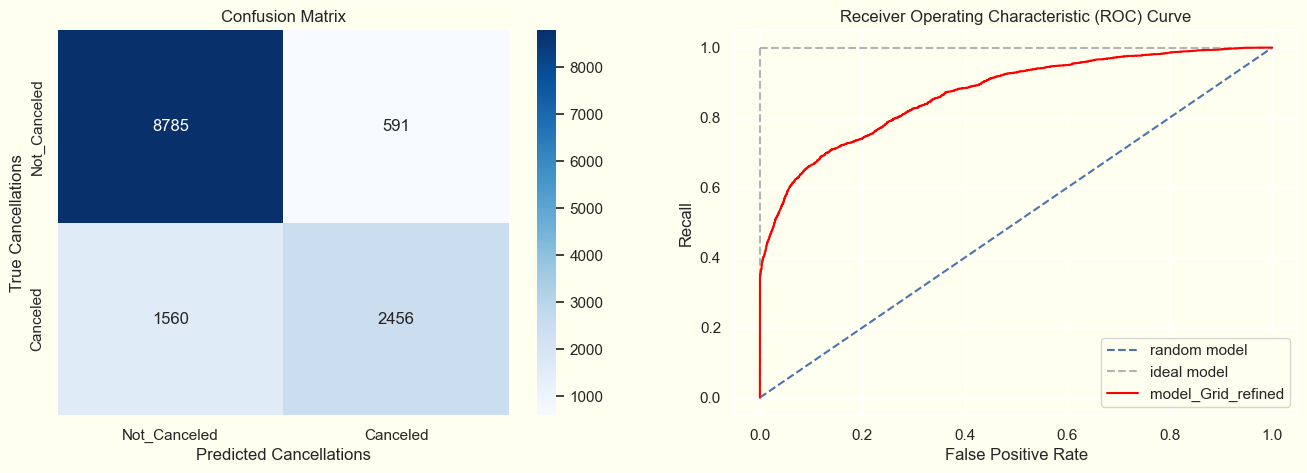

In [54]:
# Generate the classification report
print("Classification Report for Random Forest \n-------------------------------------")
print(classification_report(y_test,
                            model_Grid_refined.predict(X_test),
                            target_names=['Not_Canceled', 'Canceled'])
      )

# ---------------------------------------------------------------------------
# Confusion Matrix
df_confmatrix = confusion_matrix(y_test,
                                 model_Grid_refined.predict(X_test))
fig, ax = plt.subplots(ncols=2,
                       figsize=(16, 5))

sns.heatmap(df_confmatrix,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Not_Canceled', 'Canceled'],
            yticklabels=['Not_Canceled', 'Canceled'],
            ax=ax[0])

ax[0].set(title='Confusion Matrix',
          xlabel='Predicted Cancellations',
          ylabel='True Cancellations')

# ---------------------------------------------------------------------------
# ROC-AUC Curve

# 1. Calculate the probabilities of positive class (Not_Canceled in this case)
model_pred_prob = model_Grid_refined.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC curve values: the false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test,
                                 model_pred_prob,
                                 drop_intermediate=False)

# 3. Calculate the AUC score
auc_model = roc_auc_score(y_test, model_Grid_refined.predict(X_test))
print('AUC Score', auc_model)

# 4. Plot the ROC curve

# reference lines
ax[1].plot([0, 1], ls="--", label='random model')  # <---- blue diagonal
ax[1].plot([0, 0], [1, 0], c=".7", ls='--', label='ideal model')  # <---- grey vertical
ax[1].plot([1, 1], c=".7", ls='--')  # <---- grey horizontal

ax[1].plot(fpr, tpr, color='red', label='model_Grid_refined')  # <---- roc curve

# labels
ax[1].set(title='Receiver Operating Characteristic (ROC) Curve',
          xlabel='False Positive Rate',
          ylabel='Recall')

ax[1].legend();

plt.show()

<div style="background-color:  #dbf0c9; padding: 10px;">

### 10. Feature Importance

</div>


,Importance
deposit_type_Non Refund,0.269443
total_of_special_requests,0.133866
lead_time,0.131561
previous_cancellations,0.064259
required_car_parking_spaces,0.055390
market_segment_Online TA,0.048830
booking_changes,0.048340
customer_type_Transient,0.041486
market_segment_Groups,0.030726
distribution_channel_TA/TO,0.025445


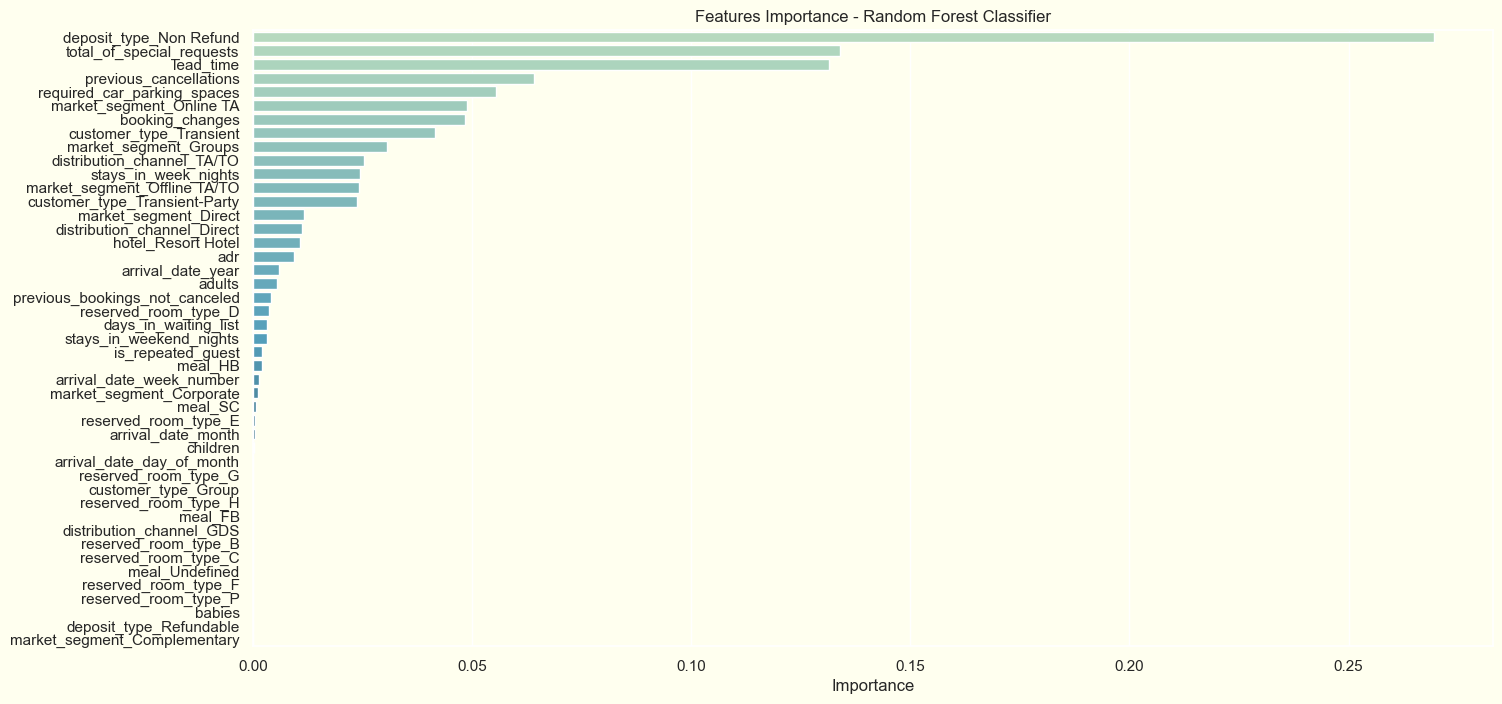

In [56]:
# Initialize the RandomForestClassifier with the specified hyperparameters
rf_model = RandomForestClassifier(
                                    criterion='entropy',
                                    max_depth=10,
                                    max_features='sqrt',
                                    max_leaf_nodes=20,
                                    min_samples_leaf=5,
                                    min_samples_split=20,
                                    random_state=42
                                )

# Fit the model to the train data
rf_model.fit(X_train_resampled, y_train_resampled)

# Get the feature importance according to Random Forest
feature_importances = pd.DataFrame(rf_model.feature_importances_,
                               index = list(X_train_resampled.columns),
                               columns = ['Importance'])

# Sort the features according to their importance in descending order
feature_importances_sorted = feature_importances.sort_values(by = 'Importance',
                                                     ascending = False)

display(feature_importances_sorted)

# -----------------------------------------------------------
# Plot features scores

plt.figure(figsize = (16,8))

sns.barplot(x = feature_importances_sorted['Importance'],
            y = feature_importances_sorted.index,
            orient = 'h',
            palette = 'GnBu_d')

plt.title("Features Importance - Random Forest Classifier")
plt.show()

I will set a threshold (in this case, s = 0.01) to determine the features I will keep to re-train the model:


In [31]:
# Set a threshold for feature importance
threshold = 0.01

# Select features with importance higher than the threshold
important_features = feature_importances_sorted[feature_importances_sorted['Importance'] > threshold].index.tolist()

important_features

['deposit_type_Non Refund',
 'lead_time',
 'total_of_special_requests',
 'previous_cancellations',
 'required_car_parking_spaces',
 'booking_changes',
 'customer_type_Transient',
 'market_segment_Groups',
 'market_segment_Online TA',
 'customer_type_Transient-Party',
 'distribution_channel_TA/TO',
 'market_segment_Offline TA/TO',
 'stays_in_week_nights',
 'adr',
 'market_segment_Direct',
 'assigned_room_type_D',
 'hotel_Resort Hotel',
 'distribution_channel_Direct']

In [33]:
# Create a new DataFrame with only important features
X_train_important = X_train_resampled[important_features]
X_test_important = X_test[important_features]

# Train the Random Forest with only important features
rf_model_important = RandomForestClassifier(
    criterion='entropy',
    max_depth=10,
    max_features='sqrt',
    max_leaf_nodes=20,
    min_samples_leaf=5,
    min_samples_split=20,
    random_state=42
)

# Fit the model on the reduced set of features
rf_model_important.fit(X_train_important, y_train_resampled)

# Evaluate the model performance
train_accuracy = rf_model_important.score(X_train_important, y_train_resampled)
test_accuracy = rf_model_important.score(X_test_important, y_test)

print('RandomForest \n -------------------------------------------------------------')
print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

RandomForest 
 -------------------------------------------------------------
Training Accuracy: 0.8120620620620621
Test Accuracy: 0.8366935483870968


8The accuracy remains in the same values aprox. I will apply RFE starting with 18 features:


In [36]:
from sklearn.feature_selection import RFE

# Instantiate a RandomForestClassifier
rf_model_important = RandomForestClassifier(
                                            criterion='entropy',
                                            max_depth=10,
                                            max_features='sqrt',
                                            max_leaf_nodes=20,
                                            min_samples_leaf=5,
                                            min_samples_split=20,
                                            random_state=42
                                        )

# Apply Recursive Feature Elimination
rfe = RFE(estimator=rf_model_important,
          n_features_to_select=18)                       # Specify how many features to retain

rfe.fit(X_train_resampled, y_train_resampled)

# Get the selected features
selected_features = X_train_resampled.columns[rfe.support_]
print("Selected features:", selected_features)

Selected features: Index(['lead_time', 'stays_in_week_nights', 'previous_cancellations', 'booking_changes', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'hotel_Resort Hotel', 'market_segment_Direct', 'market_segment_Groups', 'market_segment_Offline TA/TO', 'market_segment_Online TA', 'distribution_channel_Direct', 'distribution_channel_TA/TO', 'assigned_room_type_D', 'deposit_type_Non Refund', 'customer_type_Transient', 'customer_type_Transient-Party'], dtype='object')


In [37]:
selected_features_list = selected_features.tolist()

selected_features_list

['lead_time',
 'stays_in_week_nights',
 'previous_cancellations',
 'booking_changes',
 'adr',
 'required_car_parking_spaces',
 'total_of_special_requests',
 'hotel_Resort Hotel',
 'market_segment_Direct',
 'market_segment_Groups',
 'market_segment_Offline TA/TO',
 'market_segment_Online TA',
 'distribution_channel_Direct',
 'distribution_channel_TA/TO',
 'assigned_room_type_D',
 'deposit_type_Non Refund',
 'customer_type_Transient',
 'customer_type_Transient-Party']

In [38]:
# Train the Model with Reduced Features:

# Remove low-importance features
X_train_reduced = X_train_resampled[selected_features]
X_test_reduced = X_test[selected_features]

# Train the model with the reduced feature set
rf_model_important.fit(X_train_reduced, y_train_resampled)

# Evaluate the model's performance
train_accuracy = rf_model_important.score(X_train_reduced, y_train_resampled)
test_accuracy = rf_model_important.score(X_test_reduced, y_test)

print(f"Training Accuracy: {train_accuracy}")
print(f"Test Accuracy: {test_accuracy}")

Training Accuracy: 0.8126308126308126
Test Accuracy: 0.837141577060932


<div style="background-color:  #dbf0c9; padding: 10px;">

### Portfolio Summary and Interpretation

The final Random Forest model provides a realistic and interpretable baseline for hotel booking cancellation prediction.

**Final test performance**

- Accuracy: **0.84**
- Weighted F1-score: **0.83**
- AUC score: **0.774**
- Canceled-class precision: **0.81**
- Canceled-class recall: **0.61**
- Canceled-class F1-score: **0.70**

The model is relatively precise when it flags a booking as likely to be canceled, but it still misses some actual cancellations. In a hotel business context, this trade-off matters because false positives and false negatives can have different operational and revenue-management costs.

**Most important predictors**

The top drivers of cancellation risk were deposit type, total special requests, lead time, previous cancellations, parking requirements, market segment, booking changes, customer type, and distribution channel. These features suggest that cancellation behavior is shaped by customer commitment signals, booking timing, previous behavior, and sales channel patterns.

</div>

